In [1]:
import os, sys, json, hashlib, warnings, gc, glob
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    import rasterio
except ImportError:
    os.system("pip install rasterio -q")
    import rasterio

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

sns.set_theme(style="darkgrid", palette="deep", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "sans-serif",
})

# GPU check
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU detected — training will be slow on CPU.")

print(f"TensorFlow version: {tf.__version__}")
print("✅ All imports successful.")

2026-03-18 19:55:03.613760: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773863703.807234      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773863703.866176      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773863704.325632      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773863704.325672      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773863704.325675      23 computation_placer.cc:177] computation placer alr

✅ GPU detected: /physical_device:GPU:0
TensorFlow version: 2.19.0
✅ All imports successful.


In [2]:
# ============================================================
#  CONFIGURATION — KAGGLE PATHS (auto-detected)
# ============================================================
# Kaggle datasets are mounted at /kaggle/input/<dataset-name>/
# Outputs must go to /kaggle/working/

# Auto-detect Kaggle vs local environment
if Path("/kaggle/input").exists():
    # --- KAGGLE ENVIRONMENT ---
    # Search common Kaggle dataset mount paths
    _kaggle_candidates = [
        Path("/kaggle/input/eurosat-dataset"),
        Path("/kaggle/input/datasets/apollo2506/eurosat-dataset"),
    ]
    # Also search any subfolder under /kaggle/input/ dynamically
    for _p in Path("/kaggle/input").rglob("EuroSAT"):
        if _p.is_dir() and (_p / "train.csv").exists():
            _kaggle_candidates.insert(0, _p.parent)
            break
    BASE_DIR = next((p for p in _kaggle_candidates if p.exists()), _kaggle_candidates[0])
    OUTPUT_DIR = Path("/kaggle/working")
    print(f"🟢 Running on KAGGLE — found dataset at: {BASE_DIR}")
else:
    # --- LOCAL ENVIRONMENT (fallback) ---
    BASE_DIR = Path("archive")
    OUTPUT_DIR = Path(".")
    print("🟡 Running LOCALLY — update BASE_DIR if needed")

RGB_DIR = BASE_DIR / "EuroSAT"
MS_DIR  = BASE_DIR / "EuroSATallBands"

CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]

BAND_NAMES = [
    "B01-Coastal", "B02-Blue", "B03-Green", "B04-Red",
    "B05-VegRedEdge1", "B06-VegRedEdge2", "B07-VegRedEdge3",
    "B08-NIR", "B08A-NarrowNIR", "B09-WaterVapour",
    "B10-SWIR-Cirrus", "B11-SWIR1", "B12-SWIR2"
]

B04_RED   = 3
B08_NIR   = 7
B03_GREEN = 2
B11_SWIR1 = 11

SAMPLE_SIZE    = 500
NUM_CLASSES    = len(CLASS_NAMES)
BATCH_SIZE     = 32
EPOCHS         = 50
RGB_IMG_SIZE   = (224, 224)
TIF_IMG_SIZE   = (64, 64)
LEARNING_RATE  = 1e-3

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

print(f"📂 RGB dir  : {RGB_DIR}")
print(f"📂 MS dir   : {MS_DIR}")
print(f"📂 Output   : {OUTPUT_DIR}")
print(f"📋 Classes  : {NUM_CLASSES}")
print(f"⚙️  Batch    : {BATCH_SIZE} | Epochs: {EPOCHS} | LR: {LEARNING_RATE}")

🟢 Running on KAGGLE — found dataset at: /kaggle/input/datasets/apollo2506/eurosat-dataset
📂 RGB dir  : /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT
📂 MS dir   : /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
📂 Output   : /kaggle/working
📋 Classes  : 10
⚙️  Batch    : 32 | Epochs: 50 | LR: 0.001


In [3]:
# ============================================================
#  UTILITY FUNCTIONS
# ============================================================

def save_fig(filename):
    """Save figure to the output directory."""
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")

def load_csv(base_dir, name):
    df = pd.read_csv(base_dir / name)
    df.columns = [c.strip() for c in df.columns]
    return df

def get_file_hash(filepath, algo="sha256", chunk_size=8192):
    h = hashlib.new(algo)
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def load_rgb_image(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        img = Image.open(filepath).convert("RGB")
        return np.array(img)
    except Exception:
        return None

def load_ms_image(filepath):
    try:
        with rasterio.open(filepath) as src:
            data = src.read()
        return np.transpose(data, (1, 2, 0))
    except Exception:
        return None

def plot_styled_bar(data, title, xlabel, ylabel, palette="viridis", rotate=45, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(data.keys(), data.values(), color=sns.color_palette(palette, len(data)),
                  edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotate)
    for bar, val in zip(bars, data.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(data.values()) * 0.01,
                str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    return ax

print("✅ Utility functions loaded.")

✅ Utility functions loaded.


In [4]:
# ---
# ## PART 1 — DATA VALIDATION & INTEGRITY CHECKS
# ---

# %%
# ============================================================
#  1.1  Load CSVs & Label Map
# ============================================================
train_rgb = load_csv(RGB_DIR, "train.csv")
val_rgb   = load_csv(RGB_DIR, "validation.csv")
test_rgb  = load_csv(RGB_DIR, "test.csv")

train_ms = load_csv(MS_DIR, "train.csv")
val_ms   = load_csv(MS_DIR, "validation.csv")
test_ms  = load_csv(MS_DIR, "test.csv")

with open(RGB_DIR / "label_map.json") as f:
    label_map_rgb = json.load(f)
with open(MS_DIR / "label_map.json") as f:
    label_map_ms = json.load(f)

print("RGB splits  — Train:", len(train_rgb), "| Val:", len(val_rgb), "| Test:", len(test_rgb),
      "| Total:", len(train_rgb) + len(val_rgb) + len(test_rgb))
print("MS  splits  — Train:", len(train_ms),  "| Val:", len(val_ms),  "| Test:", len(test_ms),
      "| Total:", len(train_ms) + len(val_ms) + len(test_ms))

RGB splits  — Train: 18900 | Val: 5400 | Test: 2700 | Total: 27000
MS  splits  — Train: 19317 | Val: 5519 | Test: 2759 | Total: 27595


In [5]:
# ============================================================
#  1.2  Dataset Size Consistency
# ============================================================
print("=" * 60)
print("  1.2  DATASET SIZE CONSISTENCY")
print("=" * 60)

rgb_files_on_disk = []
ms_files_on_disk  = []
for cls in CLASS_NAMES:
    rgb_cls_files = list((RGB_DIR / cls).glob("*.jpg"))
    ms_cls_files  = list((MS_DIR / cls).glob("*.tif"))
    rgb_files_on_disk.extend(rgb_cls_files)
    ms_files_on_disk.extend(ms_cls_files)
    print(f"  {cls:25s}  RGB: {len(rgb_cls_files):5d}   MS: {len(ms_cls_files):5d}")

total_rgb_disk = len(rgb_files_on_disk)
total_ms_disk  = len(ms_files_on_disk)
total_rgb_csv  = len(train_rgb) + len(val_rgb) + len(test_rgb)
total_ms_csv   = len(train_ms)  + len(val_ms)  + len(test_ms)

print(f"\n  RGB on disk: {total_rgb_disk}  |  RGB in CSVs: {total_rgb_csv}  |  Match: {total_rgb_disk == total_rgb_csv}")
print(f"  MS  on disk: {total_ms_disk}   |  MS  in CSVs: {total_ms_csv}   |  Match: {total_ms_disk == total_ms_csv}")

  1.2  DATASET SIZE CONSISTENCY
  AnnualCrop                 RGB:  3000   MS:  3000
  Forest                     RGB:  3000   MS:  3000
  HerbaceousVegetation       RGB:  3000   MS:  3000
  Highway                    RGB:  2500   MS:  2500
  Industrial                 RGB:  2500   MS:  2500
  Pasture                    RGB:  2000   MS:  2000
  PermanentCrop              RGB:  2500   MS:  2500
  Residential                RGB:  3000   MS:  3000
  River                      RGB:  2500   MS:  2500
  SeaLake                    RGB:  3000   MS:  3597

  RGB on disk: 27000  |  RGB in CSVs: 27000  |  Match: True
  MS  on disk: 27597   |  MS  in CSVs: 27595   |  Match: False


In [6]:
# ============================================================
#  1.3  Verify Class-Label Mapping
# ============================================================
print("=" * 60)
print("  1.3  CLASS-LABEL MAPPING VERIFICATION")
print("=" * 60)

expected_map = {name: i for i, name in enumerate(CLASS_NAMES)}
rgb_map_ok = label_map_rgb == expected_map
ms_map_ok  = label_map_ms  == expected_map

print(f"  RGB label_map matches expected: {rgb_map_ok}")
print(f"  MS  label_map matches expected: {ms_map_ok}")
print(f"  Label map contents: {label_map_rgb}")

for split_name, df in [("train", train_rgb), ("val", val_rgb), ("test", test_rgb)]:
    unique_classes = set(df["ClassName"].unique())
    missing = set(CLASS_NAMES) - unique_classes
    extra   = unique_classes - set(CLASS_NAMES)
    print(f"  RGB {split_name:5s} — classes: {len(unique_classes)}  missing: {missing or 'None'}  extra: {extra or 'None'}")

  1.3  CLASS-LABEL MAPPING VERIFICATION
  RGB label_map matches expected: True
  MS  label_map matches expected: True
  Label map contents: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
  RGB train — classes: 10  missing: None  extra: None
  RGB val   — classes: 10  missing: None  extra: None
  RGB test  — classes: 10  missing: None  extra: None


In [7]:
# ============================================================
#  1.4  Detect Corrupted Images (sample-based)
# ============================================================
print("=" * 60)
print("  1.4  CORRUPTED IMAGE DETECTION")
print("=" * 60)

corrupted_rgb = []
for cls in CLASS_NAMES:
    for fp in (RGB_DIR / cls).glob("*.jpg"):
        try:
            img = Image.open(fp)
            img.verify()
        except Exception as e:
            corrupted_rgb.append((str(fp), str(e)))

corrupted_ms = []
sample_ms_files = np.random.choice(ms_files_on_disk, min(3000, len(ms_files_on_disk)), replace=False)
for fp in sample_ms_files:
    try:
        with rasterio.open(fp) as src:
            d = src.read()
            assert d.shape[0] == 13, f"Expected 13 bands, got {d.shape[0]}"
    except Exception as e:
        corrupted_ms.append((str(fp), str(e)))

print(f"  RGB corrupted: {len(corrupted_rgb)} / {total_rgb_disk}")
print(f"  MS  corrupted: {len(corrupted_ms)} / {len(sample_ms_files)} (sampled)")
if not corrupted_rgb and not corrupted_ms:
    print("  ✅ No corrupted images detected.")

  1.4  CORRUPTED IMAGE DETECTION
  RGB corrupted: 0 / 27000
  MS  corrupted: 0 / 3000 (sampled)
  ✅ No corrupted images detected.


In [8]:
# ============================================================
#  1.5  Missing Labels Check
# ============================================================
print("=" * 60)
print("  1.5  MISSING LABELS CHECK")
print("=" * 60)

for name, df in [("RGB-train", train_rgb), ("RGB-val", val_rgb), ("RGB-test", test_rgb),
                  ("MS-train", train_ms), ("MS-val", val_ms), ("MS-test", test_ms)]:
    null_label = df["Label"].isnull().sum()
    null_class = df["ClassName"].isnull().sum()
    null_file  = df["Filename"].isnull().sum()
    print(f"  {name:12s} — NaN Labels: {null_label}  NaN ClassName: {null_class}  NaN Filename: {null_file}")

  1.5  MISSING LABELS CHECK
  RGB-train    — NaN Labels: 0  NaN ClassName: 0  NaN Filename: 0
  RGB-val      — NaN Labels: 0  NaN ClassName: 0  NaN Filename: 0
  RGB-test     — NaN Labels: 0  NaN ClassName: 0  NaN Filename: 0
  MS-train     — NaN Labels: 0  NaN ClassName: 0  NaN Filename: 0
  MS-val       — NaN Labels: 0  NaN ClassName: 0  NaN Filename: 0
  MS-test      — NaN Labels: 0  NaN ClassName: 0  NaN Filename: 0


In [9]:
# ============================================================
#  1.6  Train/Test/Val Split Integrity
# ============================================================
print("=" * 60)
print("  1.6  SPLIT INTEGRITY — CHECKING FOR DATA LEAKAGE")
print("=" * 60)

def check_leakage(train_df, val_df, test_df, dataset_name):
    train_set = set(train_df["Filename"])
    val_set   = set(val_df["Filename"])
    test_set  = set(test_df["Filename"])
    tv = train_set & val_set
    tt = train_set & test_set
    vt = val_set   & test_set
    print(f"  [{dataset_name}] Train ∩ Val  overlap: {len(tv)}")
    print(f"  [{dataset_name}] Train ∩ Test overlap: {len(tt)}")
    print(f"  [{dataset_name}] Val   ∩ Test overlap: {len(vt)}")
    if not tv and not tt and not vt:
        print(f"  ✅ [{dataset_name}] No data leakage detected.")
    return tv, tt, vt

check_leakage(train_rgb, val_rgb, test_rgb, "RGB")
check_leakage(train_ms,  val_ms,  test_ms,  "MS")

  1.6  SPLIT INTEGRITY — CHECKING FOR DATA LEAKAGE
  [RGB] Train ∩ Val  overlap: 0
  [RGB] Train ∩ Test overlap: 0
  [RGB] Val   ∩ Test overlap: 0
  ✅ [RGB] No data leakage detected.
  [MS] Train ∩ Val  overlap: 0
  [MS] Train ∩ Test overlap: 0
  [MS] Val   ∩ Test overlap: 0
  ✅ [MS] No data leakage detected.


(set(), set(), set())

In [10]:
# ============================================================
#  1.7  Duplicate Image Detection (Hash-Based)
# ============================================================
print("=" * 60)
print("  1.7  DUPLICATE IMAGE DETECTION (SHA-256)")
print("=" * 60)

rgb_hashes = {}
rgb_duplicates = []
for fp in rgb_files_on_disk:
    h = get_file_hash(str(fp))
    if h in rgb_hashes:
        rgb_duplicates.append((str(fp), str(rgb_hashes[h])))
    else:
        rgb_hashes[h] = fp

print(f"  RGB unique hashes : {len(rgb_hashes)}")
print(f"  RGB duplicates    : {len(rgb_duplicates)}")
if not rgb_duplicates:
    print("  ✅ No duplicate RGB images found.")

print("\n  🔍 Part 1 Complete — Dataset integrity verified.")

  1.7  DUPLICATE IMAGE DETECTION (SHA-256)
  RGB unique hashes : 27000
  RGB duplicates    : 0
  ✅ No duplicate RGB images found.

  🔍 Part 1 Complete — Dataset integrity verified.


In [11]:
# ---
# ## PART 2 — CLASS DISTRIBUTION ANALYSIS
# ---

# %%
# ============================================================
#  2.1  Class Frequency Table
# ============================================================
print("=" * 60)
print("  PART 2 — CLASS DISTRIBUTION ANALYSIS")
print("=" * 60)

rgb_class_counts = {}
for cls in CLASS_NAMES:
    rgb_class_counts[cls] = len(list((RGB_DIR / cls).glob("*.jpg")))

total = sum(rgb_class_counts.values())
freq_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Count": [rgb_class_counts[c] for c in CLASS_NAMES],
    "Percentage": [rgb_class_counts[c] / total * 100 for c in CLASS_NAMES]
}).sort_values("Count", ascending=False).reset_index(drop=True)

print(freq_df.to_string(index=False))
print(f"\nTotal images: {total}")
print(f"Imbalance Ratio (max/min): {freq_df['Count'].max() / freq_df['Count'].min():.2f}")

  PART 2 — CLASS DISTRIBUTION ANALYSIS
               Class  Count  Percentage
          AnnualCrop   3000   11.111111
              Forest   3000   11.111111
HerbaceousVegetation   3000   11.111111
         Residential   3000   11.111111
             SeaLake   3000   11.111111
             Highway   2500    9.259259
       PermanentCrop   2500    9.259259
          Industrial   2500    9.259259
               River   2500    9.259259
             Pasture   2000    7.407407

Total images: 27000
Imbalance Ratio (max/min): 1.50


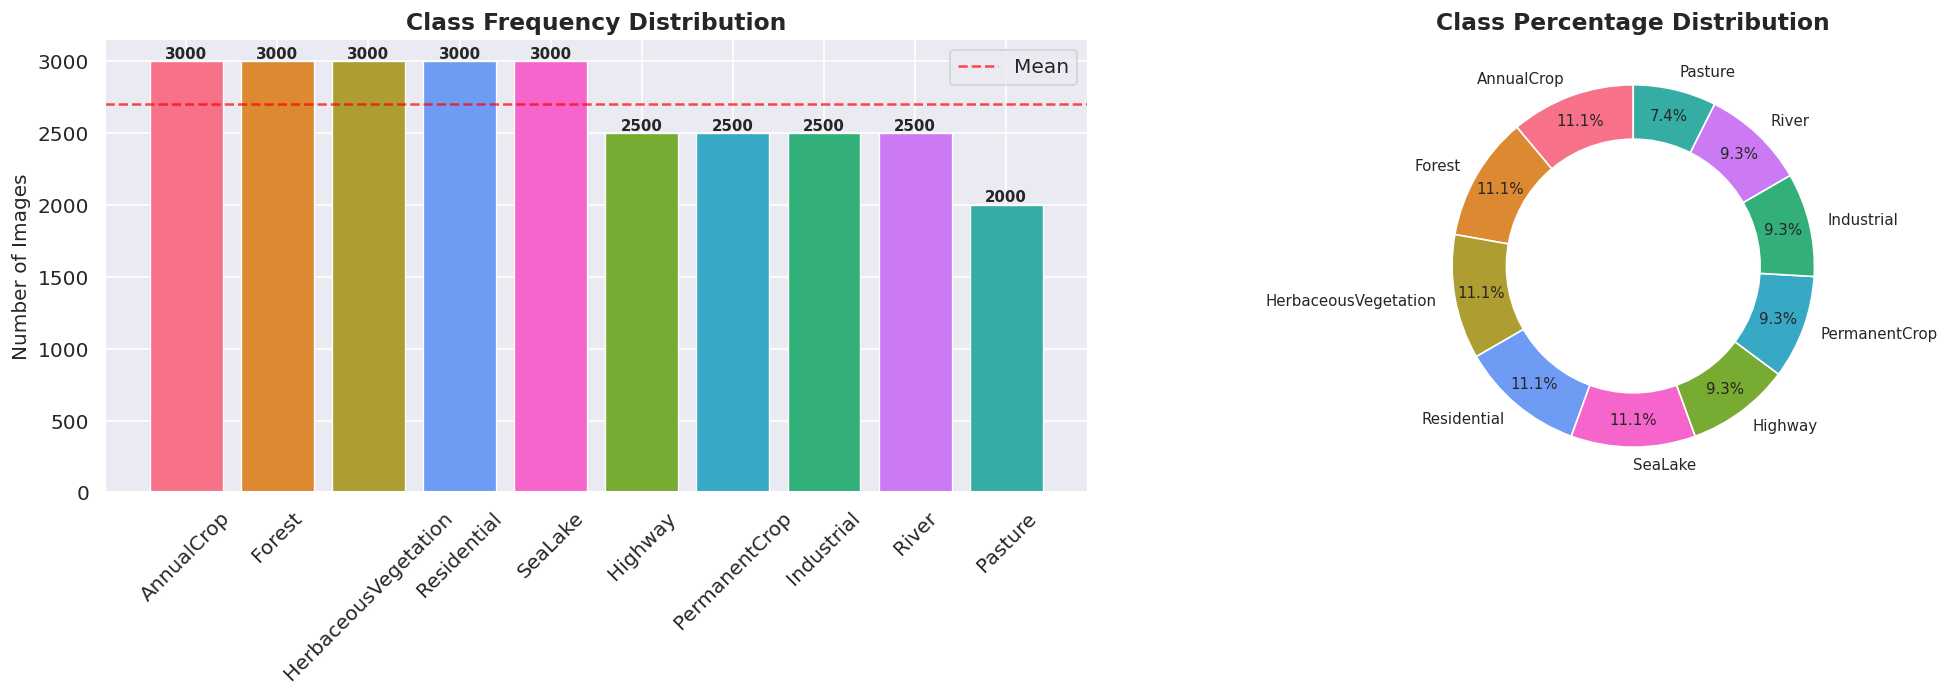

In [12]:
# ============================================================
#  2.2  Bar Plot & Pie Chart
# ============================================================
CLASS_COLORS = sns.color_palette("husl", 10)
class_color_map = dict(zip(CLASS_NAMES, CLASS_COLORS))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
bars = axes[0].bar(freq_df["Class"], freq_df["Count"],
                   color=[class_color_map[c] for c in freq_df["Class"]],
                   edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Frequency Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=45)
for bar, val in zip(bars, freq_df["Count"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(val), ha="center", fontsize=9, fontweight="bold")
axes[0].axhline(y=total / len(CLASS_NAMES), color="red", linestyle="--", alpha=0.7, label="Mean")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    freq_df["Count"], labels=freq_df["Class"], autopct="%1.1f%%",
    colors=[class_color_map[c] for c in freq_df["Class"]],
    startangle=90, pctdistance=0.85, textprops={"fontsize": 9})
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
axes[1].add_artist(centre_circle)
axes[1].set_title("Class Percentage Distribution", fontweight="bold")
plt.tight_layout()
save_fig("class_distribution.png")
plt.show()


📊 Split Distribution:

                      Train  Validation  Test
Class                                        
AnnualCrop             2100         600   300
Forest                 2100         600   300
HerbaceousVegetation   2100         600   300
Highway                1750         500   250
Industrial             1750         500   250
Pasture                1400         400   200
PermanentCrop          1750         500   250
Residential            2100         600   300
River                  1750         500   250
SeaLake                2100         600   300


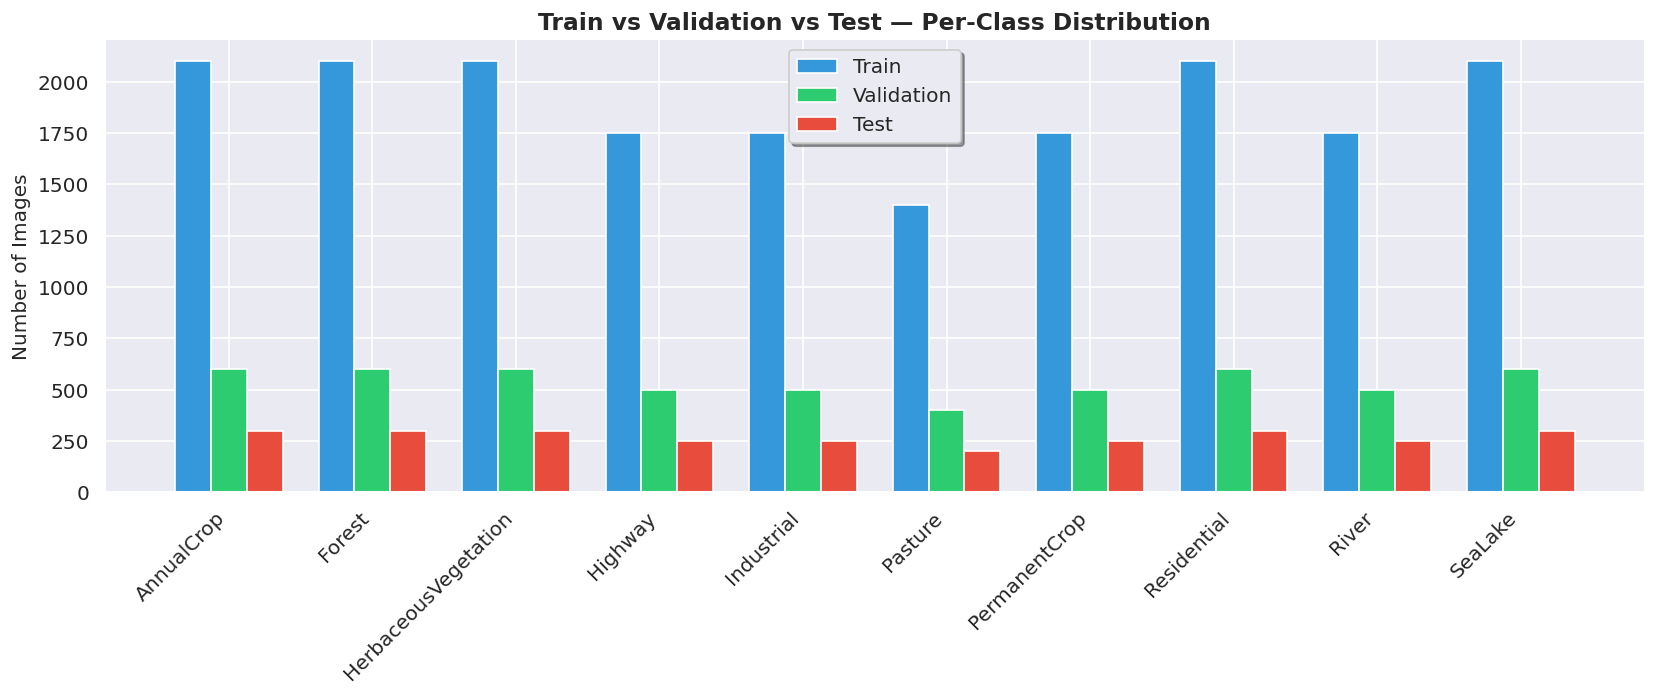

In [13]:
# ============================================================
#  2.3  Train / Validation / Test Distribution
# ============================================================
split_data = {}
for split_name, df in [("Train", train_rgb), ("Validation", val_rgb), ("Test", test_rgb)]:
    counts = df["ClassName"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
    split_data[split_name] = counts

split_df = pd.DataFrame(split_data)
split_df.index.name = "Class"
print("\n📊 Split Distribution:\n")
print(split_df.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLASS_NAMES))
width = 0.25
for i, (split_name, color) in enumerate(zip(["Train", "Validation", "Test"],
                                              ["#3498db", "#2ecc71", "#e74c3c"])):
    vals = split_df[split_name].values
    ax.bar(x + i * width, vals, width, label=split_name, color=color, edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("Number of Images")
ax.set_title("Train vs Validation vs Test — Per-Class Distribution", fontweight="bold")
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig("split_distribution.png")
plt.show()

In [14]:
# ============================================================
#  2.4  Imbalance Analysis
# ============================================================
imbalance_ratio = freq_df["Count"].max() / freq_df["Count"].min()
cv = freq_df["Count"].std() / freq_df["Count"].mean() * 100
print(f"  Imbalance Ratio: {imbalance_ratio:.2f}")
print(f"  Coefficient of Variation: {cv:.1f}%")
if imbalance_ratio < 1.5:
    print("  ✅ Dataset is WELL BALANCED (ratio < 1.5).")
elif imbalance_ratio < 3.0:
    print("  ⚠️  MILD IMBALANCE detected (ratio 1.5–3.0).")
else:
    print("  🚨 SIGNIFICANT IMBALANCE (ratio > 3.0).")

total_all = len(train_rgb) + len(val_rgb) + len(test_rgb)
print(f"\n  Split ratios: Train {len(train_rgb)/total_all:.1%} | Val {len(val_rgb)/total_all:.1%} | Test {len(test_rgb)/total_all:.1%}")

  Imbalance Ratio: 1.50
  Coefficient of Variation: 12.9%
  ⚠️  MILD IMBALANCE detected (ratio 1.5–3.0).

  Split ratios: Train 70.0% | Val 20.0% | Test 10.0%


  PART 3 — RGB IMAGE EDA

📊 Global Pixel Statistics:
     Mean    Std  Min    Max
R   87.26  51.17  8.0  255.0
G   96.73  34.48  8.0  255.0
B  103.77  29.34  5.0  255.0


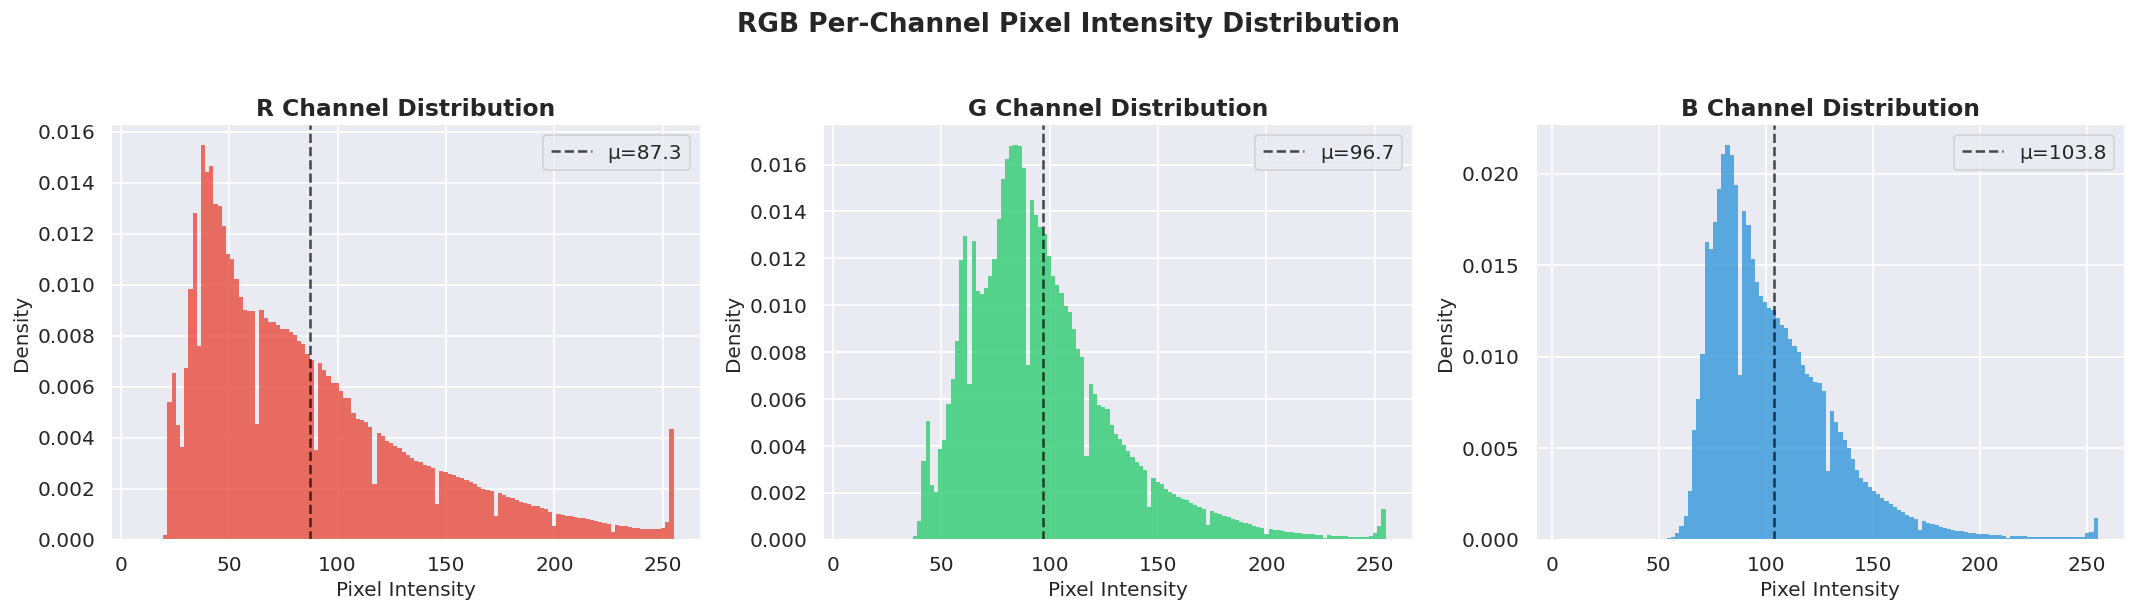

In [15]:
# ============================================================
#  3.1–3.6  RGB Pixel Stats, Histograms, HSV, Texture
# ============================================================
print("=" * 60)
print("  PART 3 — RGB IMAGE EDA")
print("=" * 60)

per_class_stats = {}
all_pixels = {"R": [], "G": [], "B": []}
stats_sample = min(300, total_rgb_disk // len(CLASS_NAMES))

for cls in CLASS_NAMES:
    cls_files = list((RGB_DIR / cls).glob("*.jpg"))
    sampled = np.random.choice(cls_files, min(stats_sample, len(cls_files)), replace=False)
    cls_pixels = {"R": [], "G": [], "B": []}
    for fp in sampled:
        img = load_rgb_image(str(fp))
        if img is not None:
            cls_pixels["R"].append(img[:, :, 0].flatten())
            cls_pixels["G"].append(img[:, :, 1].flatten())
            cls_pixels["B"].append(img[:, :, 2].flatten())
    merged = {ch: np.concatenate(cls_pixels[ch]) for ch in "RGB" if cls_pixels[ch[0]]}
    per_class_stats[cls] = {
        ch: {"mean": merged[ch].mean(), "std": merged[ch].std(),
             "min": merged[ch].min(), "max": merged[ch].max()}
        for ch in ["R", "G", "B"] if ch in merged
    }
    for ch in ["R", "G", "B"]:
        if ch in merged:
            all_pixels[ch].append(merged[ch])

global_stats = {}
for ch in ["R", "G", "B"]:
    arr = np.concatenate(all_pixels[ch])
    global_stats[ch] = {"mean": arr.mean(), "std": arr.std(), "min": arr.min(), "max": arr.max()}

print("\n📊 Global Pixel Statistics:")
stats_table = pd.DataFrame(global_stats).T
stats_table.columns = ["Mean", "Std", "Min", "Max"]
print(stats_table.round(2).to_string())

# Per-channel histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_rgb = ["#e74c3c", "#2ecc71", "#3498db"]
for i, (ch, color) in enumerate(zip(["R", "G", "B"], colors_rgb)):
    data = np.concatenate(all_pixels[ch])
    axes[i].hist(data, bins=128, color=color, alpha=0.8, density=True, edgecolor="none")
    axes[i].axvline(global_stats[ch]["mean"], color="black", linestyle="--", alpha=0.7,
                    label=f'μ={global_stats[ch]["mean"]:.1f}')
    axes[i].set_title(f"{ch} Channel Distribution", fontweight="bold")
    axes[i].set_xlabel("Pixel Intensity")
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].spines[["top", "right"]].set_visible(False)
plt.suptitle("RGB Per-Channel Pixel Intensity Distribution", fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("rgb_channel_histograms.png")
plt.show()

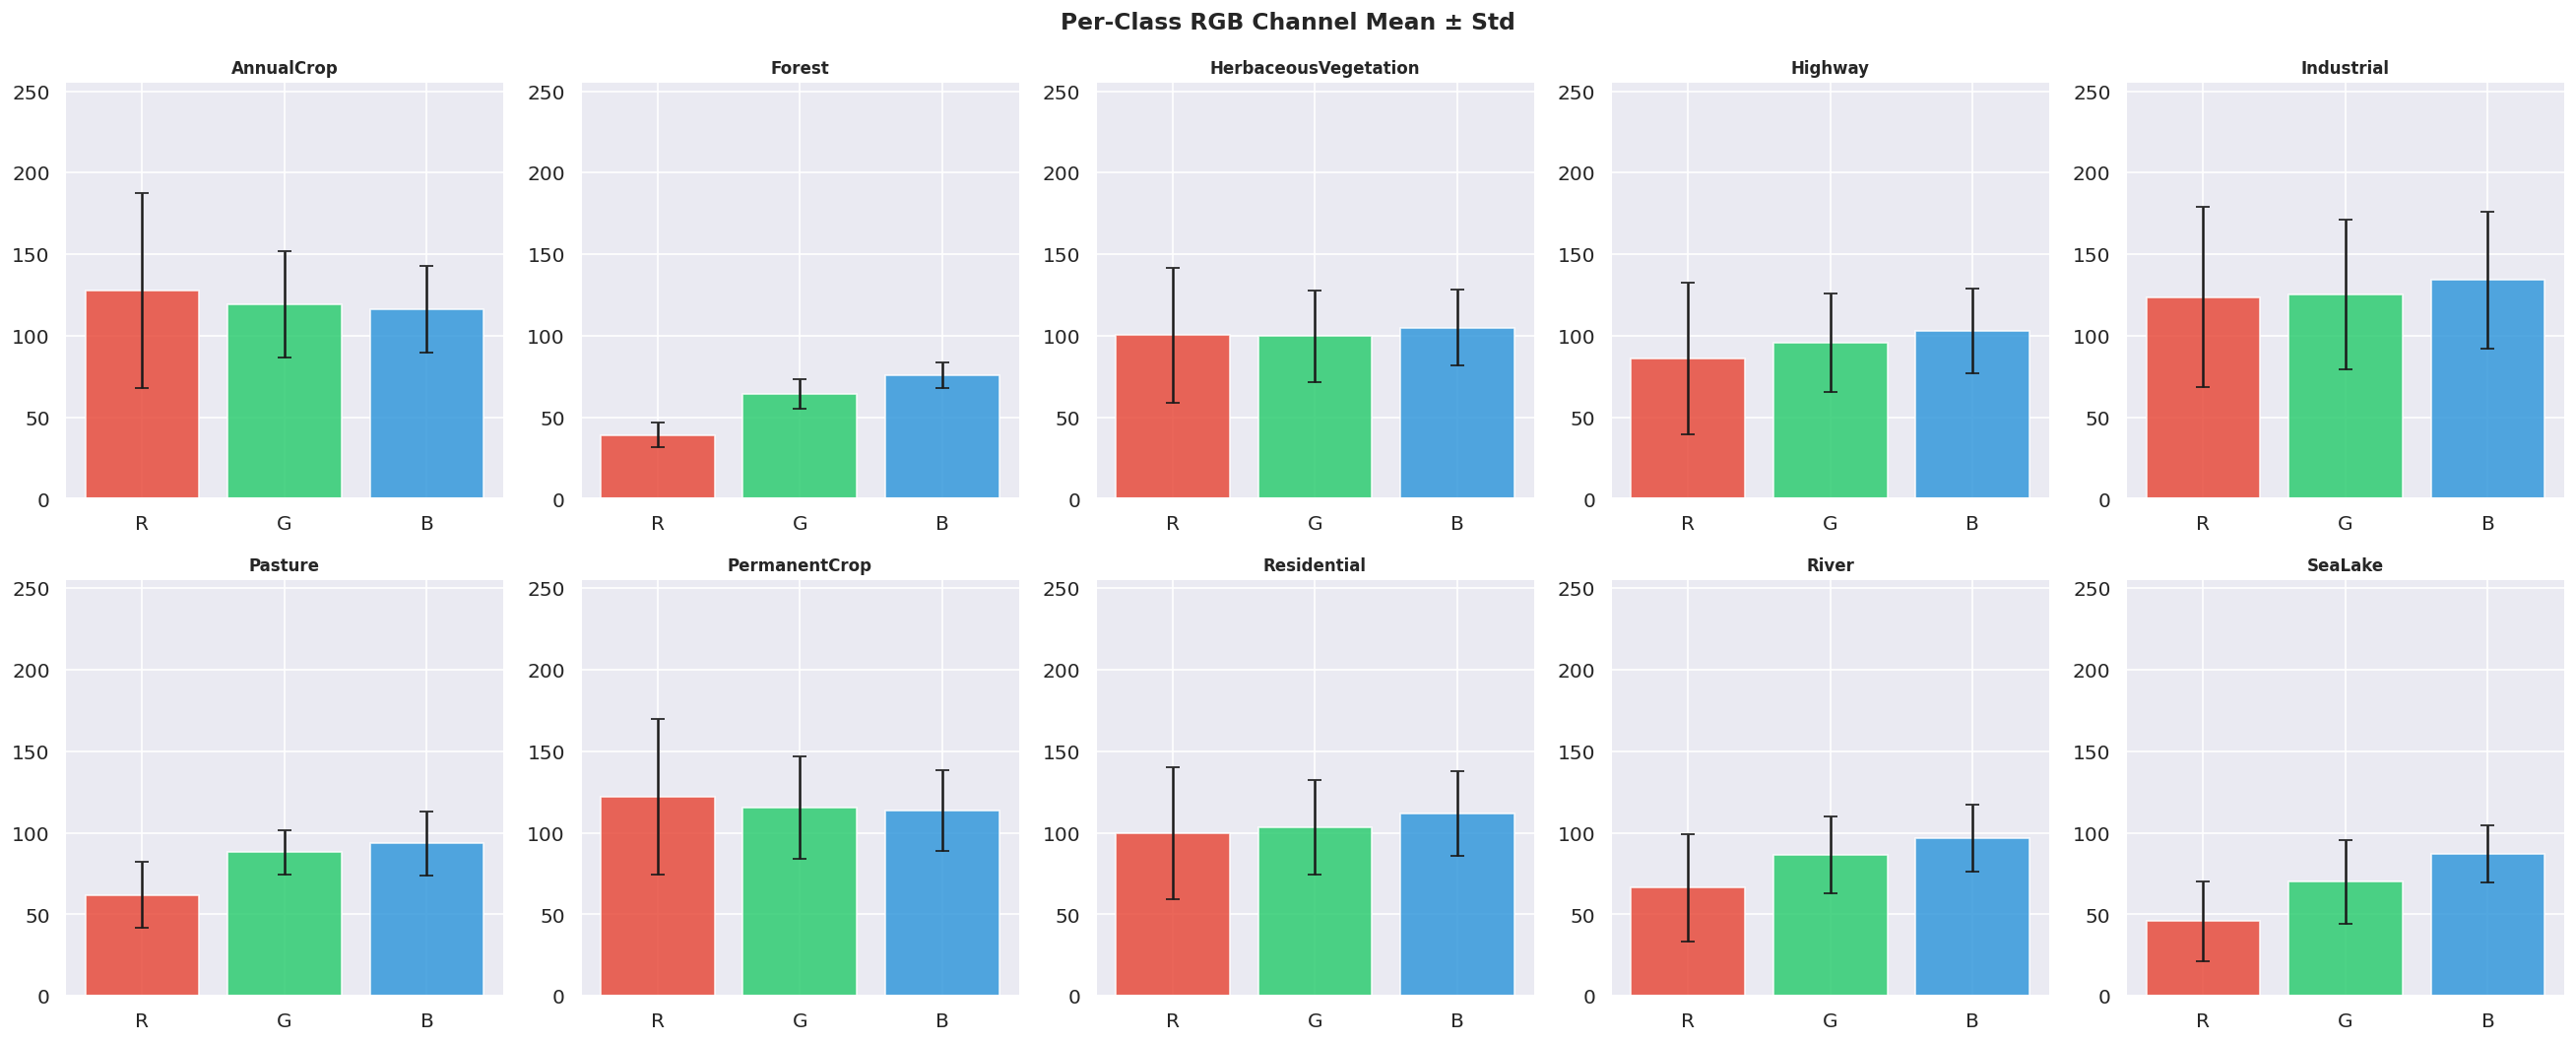

In [16]:
# Per-class bar charts
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for idx, cls in enumerate(CLASS_NAMES):
    s = per_class_stats[cls]
    x_pos = np.arange(3)
    means = [s["R"]["mean"], s["G"]["mean"], s["B"]["mean"]]
    stds  = [s["R"]["std"],  s["G"]["std"],  s["B"]["std"]]
    axes[idx].bar(x_pos, means, yerr=stds, color=colors_rgb,
                  edgecolor="white", capsize=4, alpha=0.85)
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(["R", "G", "B"])
    axes[idx].set_title(cls, fontweight="bold", fontsize=10)
    axes[idx].set_ylim(0, 255)
    axes[idx].spines[["top", "right"]].set_visible(False)
plt.suptitle("Per-Class RGB Channel Mean ± Std", fontweight="bold", fontsize=14)
plt.tight_layout()
save_fig("per_class_rgb_stats.png")
plt.show()

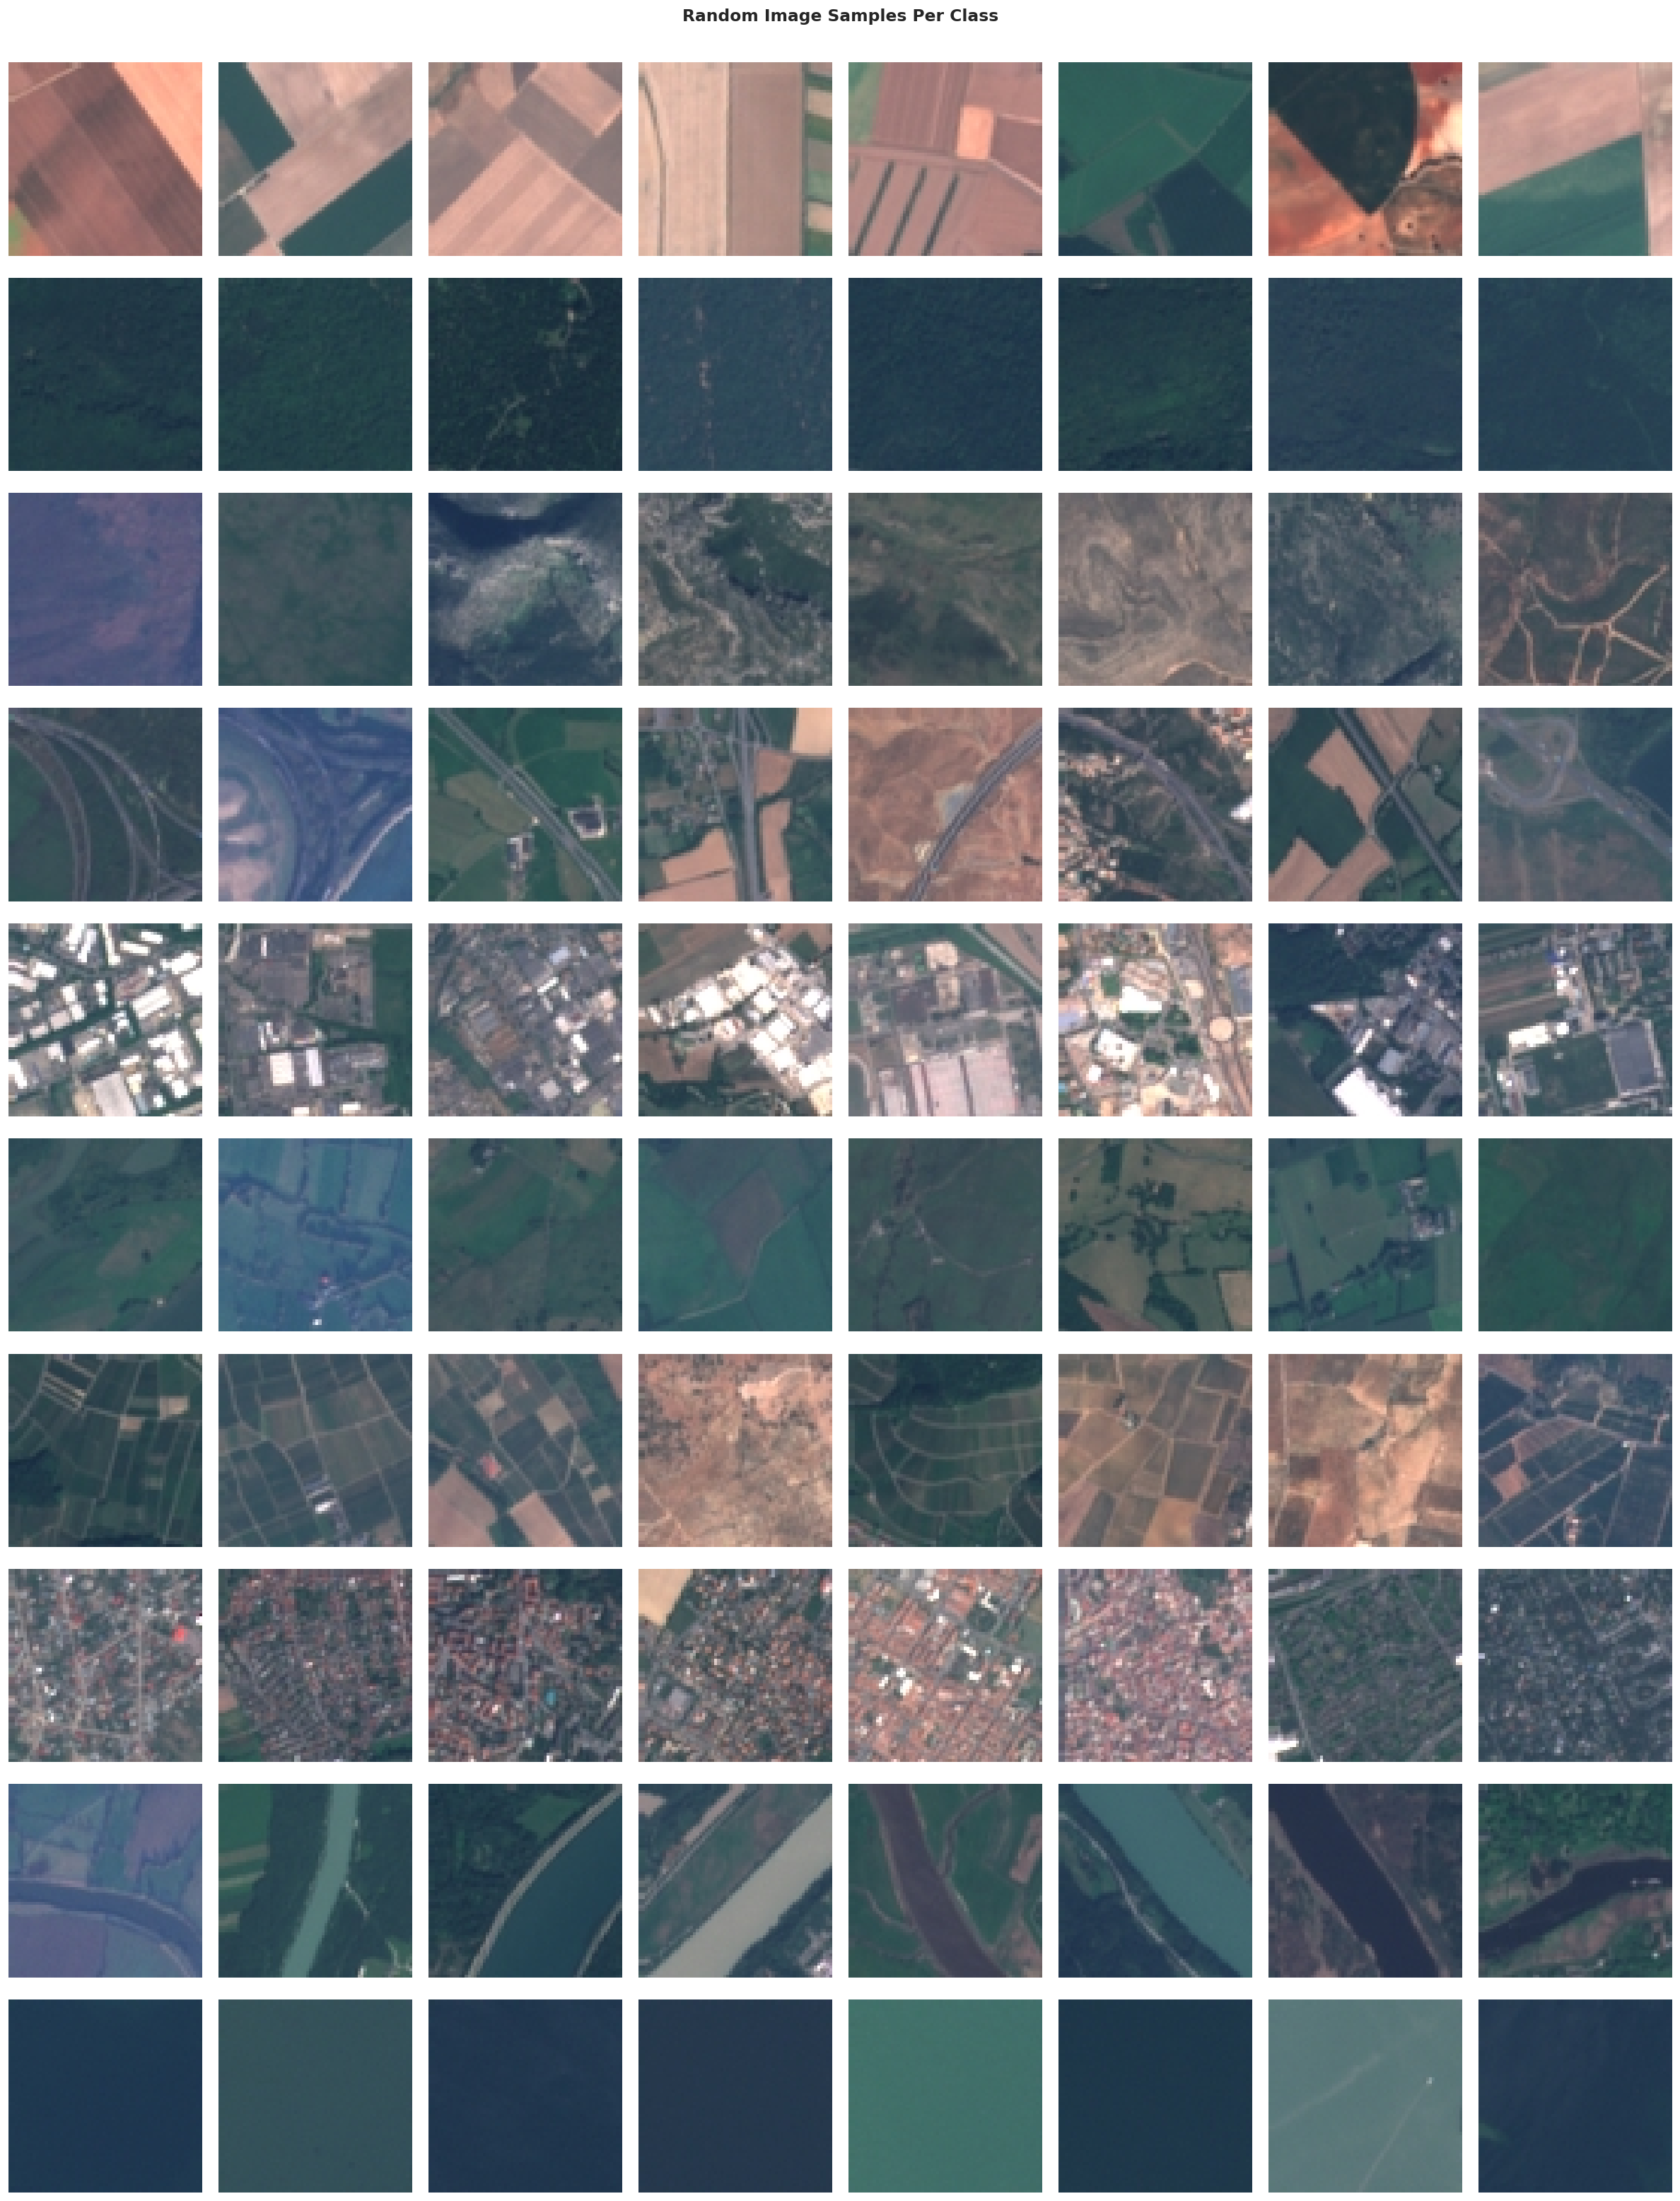

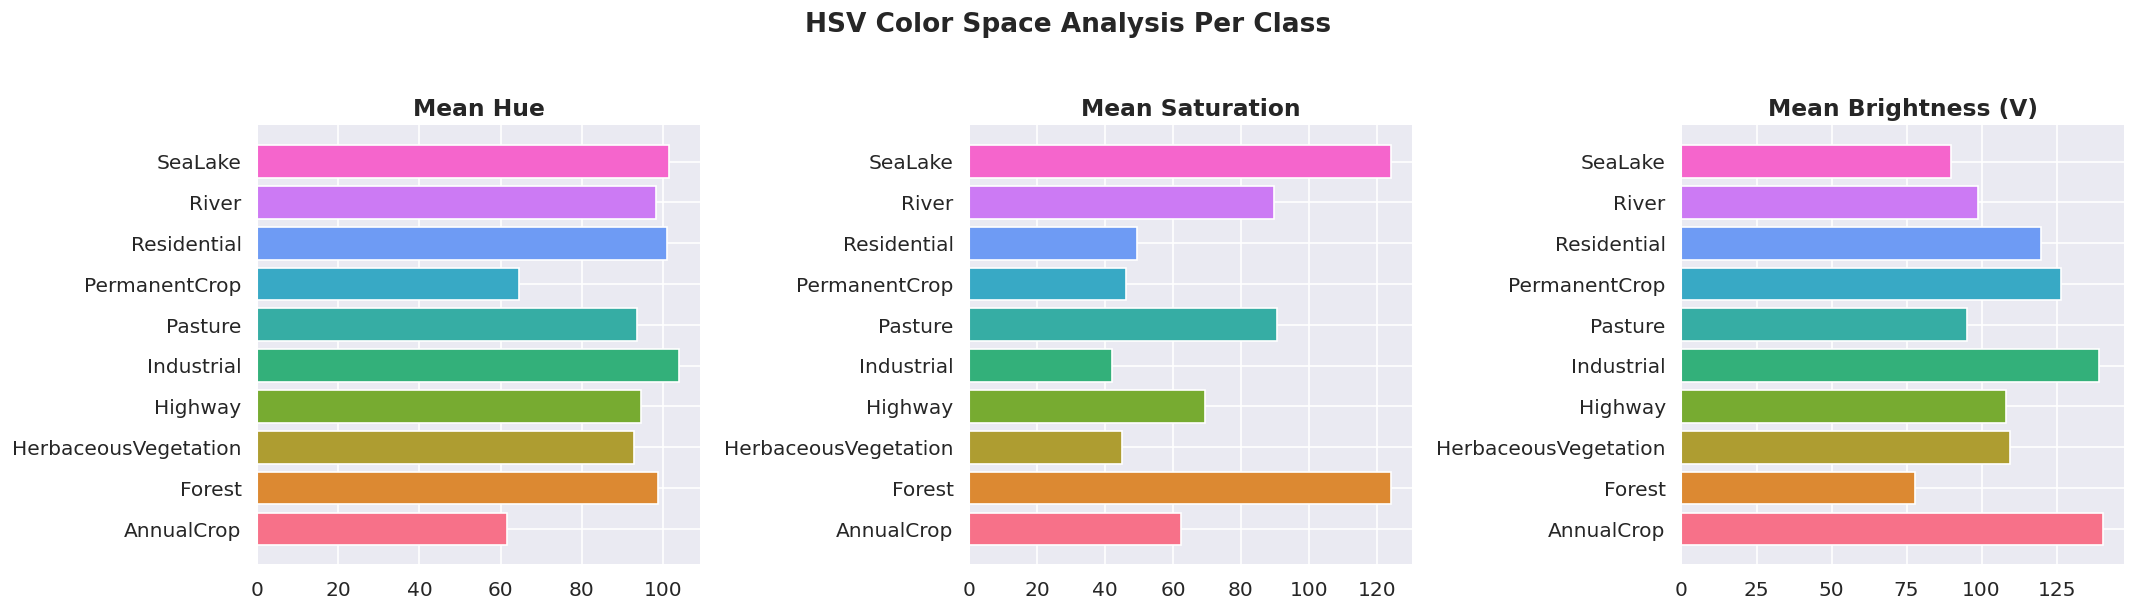

In [17]:
# Random image grid
fig, axes = plt.subplots(10, 8, figsize=(20, 26))
for row, cls in enumerate(CLASS_NAMES):
    cls_files = list((RGB_DIR / cls).glob("*.jpg"))
    sampled = np.random.choice(cls_files, 8, replace=False)
    for col, fp in enumerate(sampled):
        img = load_rgb_image(str(fp))
        if img is not None:
            axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=10, fontweight="bold", rotation=0,
                                       labelpad=80, ha="right", va="center")
plt.suptitle("Random Image Samples Per Class", fontweight="bold", fontsize=14, y=1.0)
plt.tight_layout()
save_fig("random_grid_per_class.png")
plt.show()

# HSV analysis
hsv_stats = {}
for cls in CLASS_NAMES:
    cls_files = list((RGB_DIR / cls).glob("*.jpg"))
    sampled = np.random.choice(cls_files, min(200, len(cls_files)), replace=False)
    hues, sats, vals = [], [], []
    for fp in sampled:
        img = load_rgb_image(str(fp))
        if img is not None:
            hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
            hues.append(hsv[:, :, 0].mean())
            sats.append(hsv[:, :, 1].mean())
            vals.append(hsv[:, :, 2].mean())
    hsv_stats[cls] = {"Hue": np.mean(hues), "Saturation": np.mean(sats), "Brightness": np.mean(vals)}

hsv_df = pd.DataFrame(hsv_stats).T
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, title) in enumerate(zip(["Hue", "Saturation", "Brightness"],
                                       ["Mean Hue", "Mean Saturation", "Mean Brightness (V)"])):
    v = hsv_df[col].values
    colors = [class_color_map[c] for c in hsv_df.index]
    axes[i].barh(hsv_df.index, v, color=colors, edgecolor="white")
    axes[i].set_title(title, fontweight="bold")
    axes[i].spines[["top", "right"]].set_visible(False)
plt.suptitle("HSV Color Space Analysis Per Class", fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("hsv_analysis.png")
plt.show()

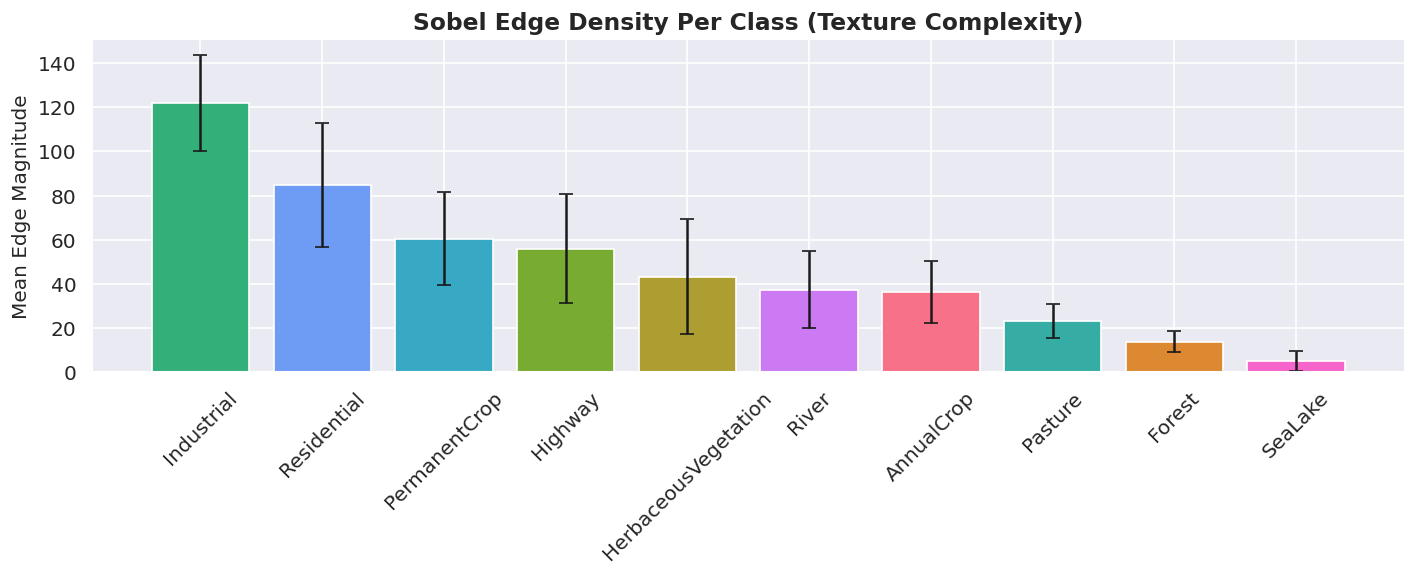

In [18]:
# Sobel edge density
edge_densities = {}
for cls in CLASS_NAMES:
    cls_files = list((RGB_DIR / cls).glob("*.jpg"))
    sampled = np.random.choice(cls_files, min(200, len(cls_files)), replace=False)
    densities = []
    for fp in sampled:
        img = load_rgb_image(str(fp))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
            sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
            mag = np.sqrt(sobelx**2 + sobely**2)
            densities.append(mag.mean())
    edge_densities[cls] = {"mean": np.mean(densities), "std": np.std(densities)}

edge_df = pd.DataFrame(edge_densities).T.sort_values("mean", ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(edge_df.index, edge_df["mean"], yerr=edge_df["std"],
              color=[class_color_map[c] for c in edge_df.index],
              edgecolor="white", capsize=4)
ax.set_title("Sobel Edge Density Per Class (Texture Complexity)", fontweight="bold")
ax.set_ylabel("Mean Edge Magnitude")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig("edge_density.png")
plt.show()

  PART 4 — MULTISPECTRAL (13-BAND) EDA
  Loaded AnnualCrop: 200 samples
  Loaded Forest: 200 samples
  Loaded HerbaceousVegetation: 200 samples
  Loaded Highway: 200 samples
  Loaded Industrial: 200 samples
  Loaded Pasture: 200 samples
  Loaded PermanentCrop: 200 samples
  Loaded Residential: 200 samples
  Loaded River: 200 samples
  Loaded SeaLake: 200 samples

📊 Band-wise Global Statistics:
           Band    Mean     Std  Min   Max  Median
    B01-Coastal 1355.28  242.14  849  4090  1312.0
       B02-Blue 1118.00  333.06  116 27997  1045.0
      B03-Green 1040.12  393.09   53 26521   971.0
        B04-Red  941.32  591.43  187 28000   784.0
B05-VegRedEdge1 1198.24  563.17  188 17829  1153.0
B06-VegRedEdge2 2029.44  867.23  157 19485  2122.0
B07-VegRedEdge3 2410.10 1099.26  132 19937  2491.0
        B08-NIR 2337.50 1132.56   69 28002  2429.0
 B08A-NarrowNIR  745.74  407.60   44  2567   714.0
B09-WaterVapour   12.59    6.64    2   137    12.0
B10-SWIR-Cirrus 1824.56  983.61    2 17905

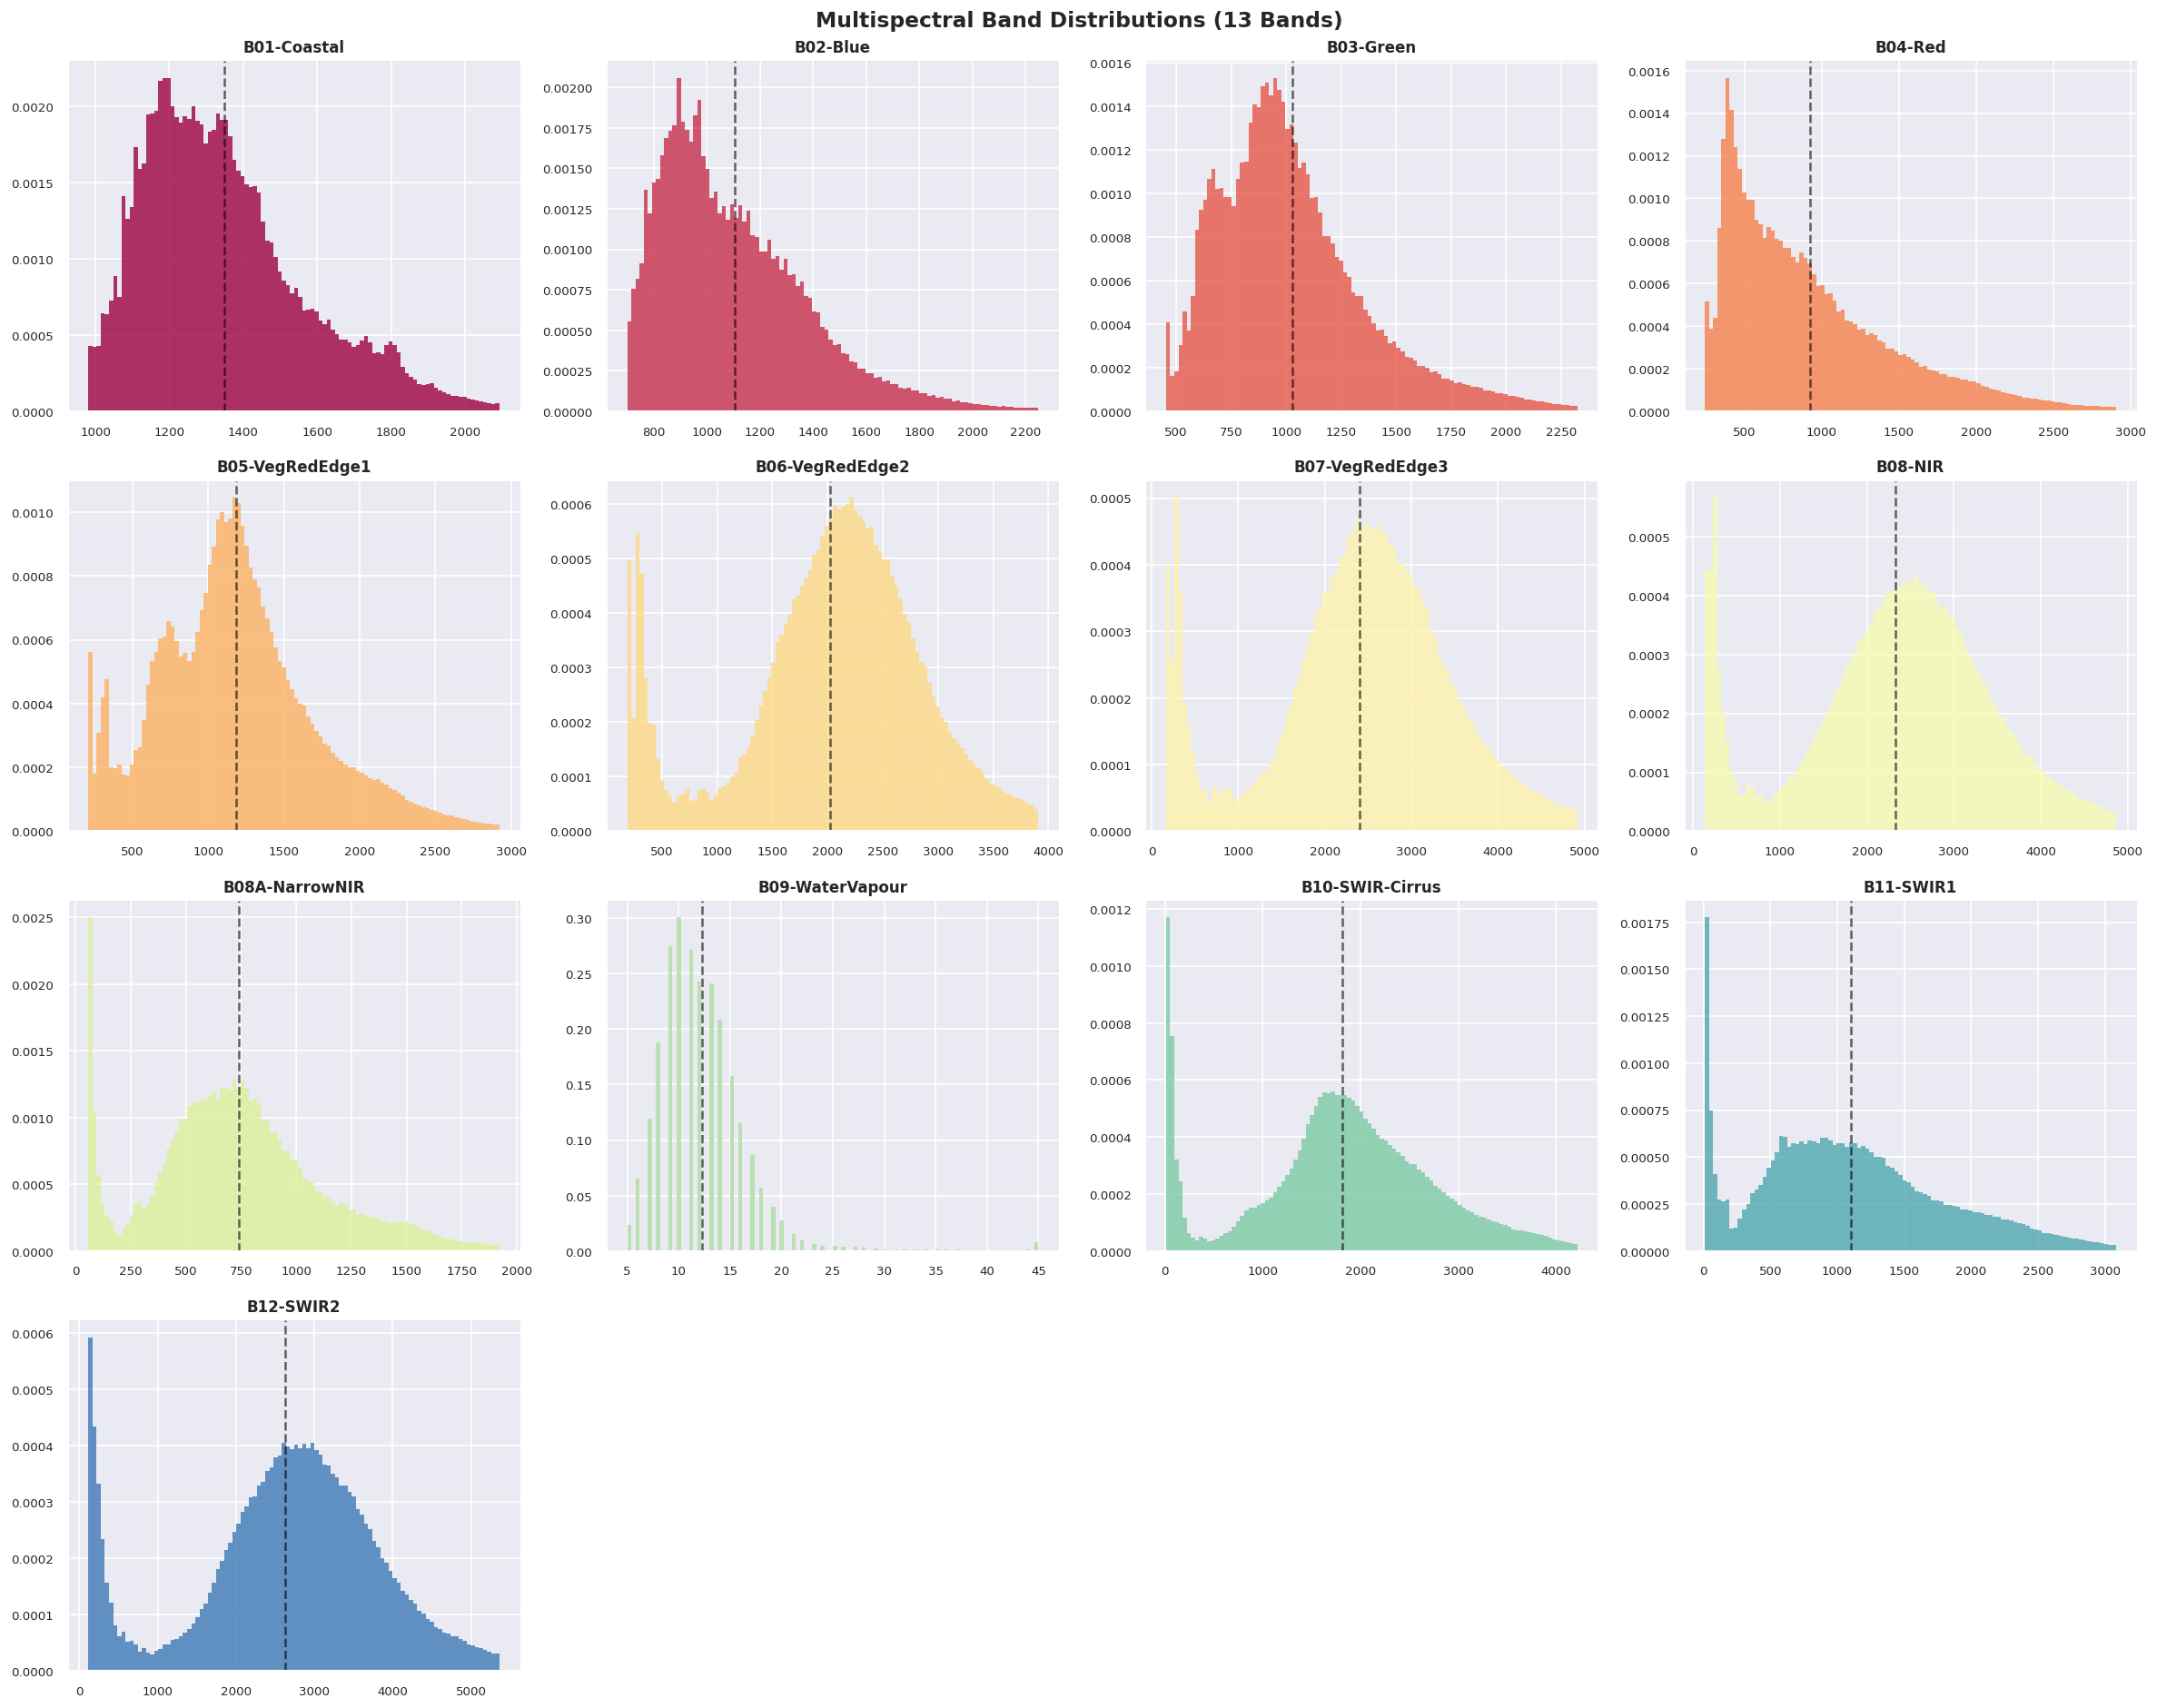

In [19]:
# ---
# ## PART 4 — MULTISPECTRAL (13-BAND) EDA
# ---

# %%
# ============================================================
#  4.1–4.6  Band Stats, Histograms, Boxplots, Spectral Sigs, Indices, Correlations
# ============================================================
print("=" * 60)
print("  PART 4 — MULTISPECTRAL (13-BAND) EDA")
print("=" * 60)

ms_sample_per_class = min(SAMPLE_SIZE, 200)
ms_class_data = {}

for cls in CLASS_NAMES:
    cls_files = list((MS_DIR / cls).glob("*.tif"))
    sampled = np.random.choice(cls_files, min(ms_sample_per_class, len(cls_files)), replace=False)
    band_values = [[] for _ in range(13)]
    for fp in sampled:
        img = load_ms_image(str(fp))
        if img is not None:
            for b in range(13):
                band_values[b].append(img[:, :, b].flatten())
    ms_class_data[cls] = {
        b: np.concatenate(band_values[b]) for b in range(13) if band_values[b]
    }
    print(f"  Loaded {cls}: {len(sampled)} samples")

print("\n📊 Band-wise Global Statistics:")
band_stats_list = []
for b in range(13):
    all_band = np.concatenate([ms_class_data[cls][b] for cls in CLASS_NAMES if b in ms_class_data[cls]])
    band_stats_list.append({
        "Band": BAND_NAMES[b], "Mean": all_band.mean(), "Std": all_band.std(),
        "Min": all_band.min(), "Max": all_band.max(), "Median": np.median(all_band)
    })
band_stats_df = pd.DataFrame(band_stats_list)
print(band_stats_df.round(2).to_string(index=False))

# Band histograms
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
cmap = plt.cm.Spectral
for b in range(13):
    all_band = np.concatenate([ms_class_data[cls][b] for cls in CLASS_NAMES])
    p1, p99 = np.percentile(all_band, [1, 99])
    clipped = all_band[(all_band >= p1) & (all_band <= p99)]
    axes[b].hist(clipped, bins=100, color=cmap(b / 13), alpha=0.8, density=True, edgecolor="none")
    axes[b].set_title(BAND_NAMES[b], fontweight="bold", fontsize=10)
    axes[b].axvline(clipped.mean(), color="black", linestyle="--", alpha=0.6)
    axes[b].spines[["top", "right"]].set_visible(False)
    axes[b].tick_params(labelsize=8)
for b in range(13, 16):
    axes[b].set_visible(False)
plt.suptitle("Multispectral Band Distributions (13 Bands)", fontweight="bold", fontsize=14)
plt.tight_layout()
save_fig("ms_band_histograms.png")
plt.show()

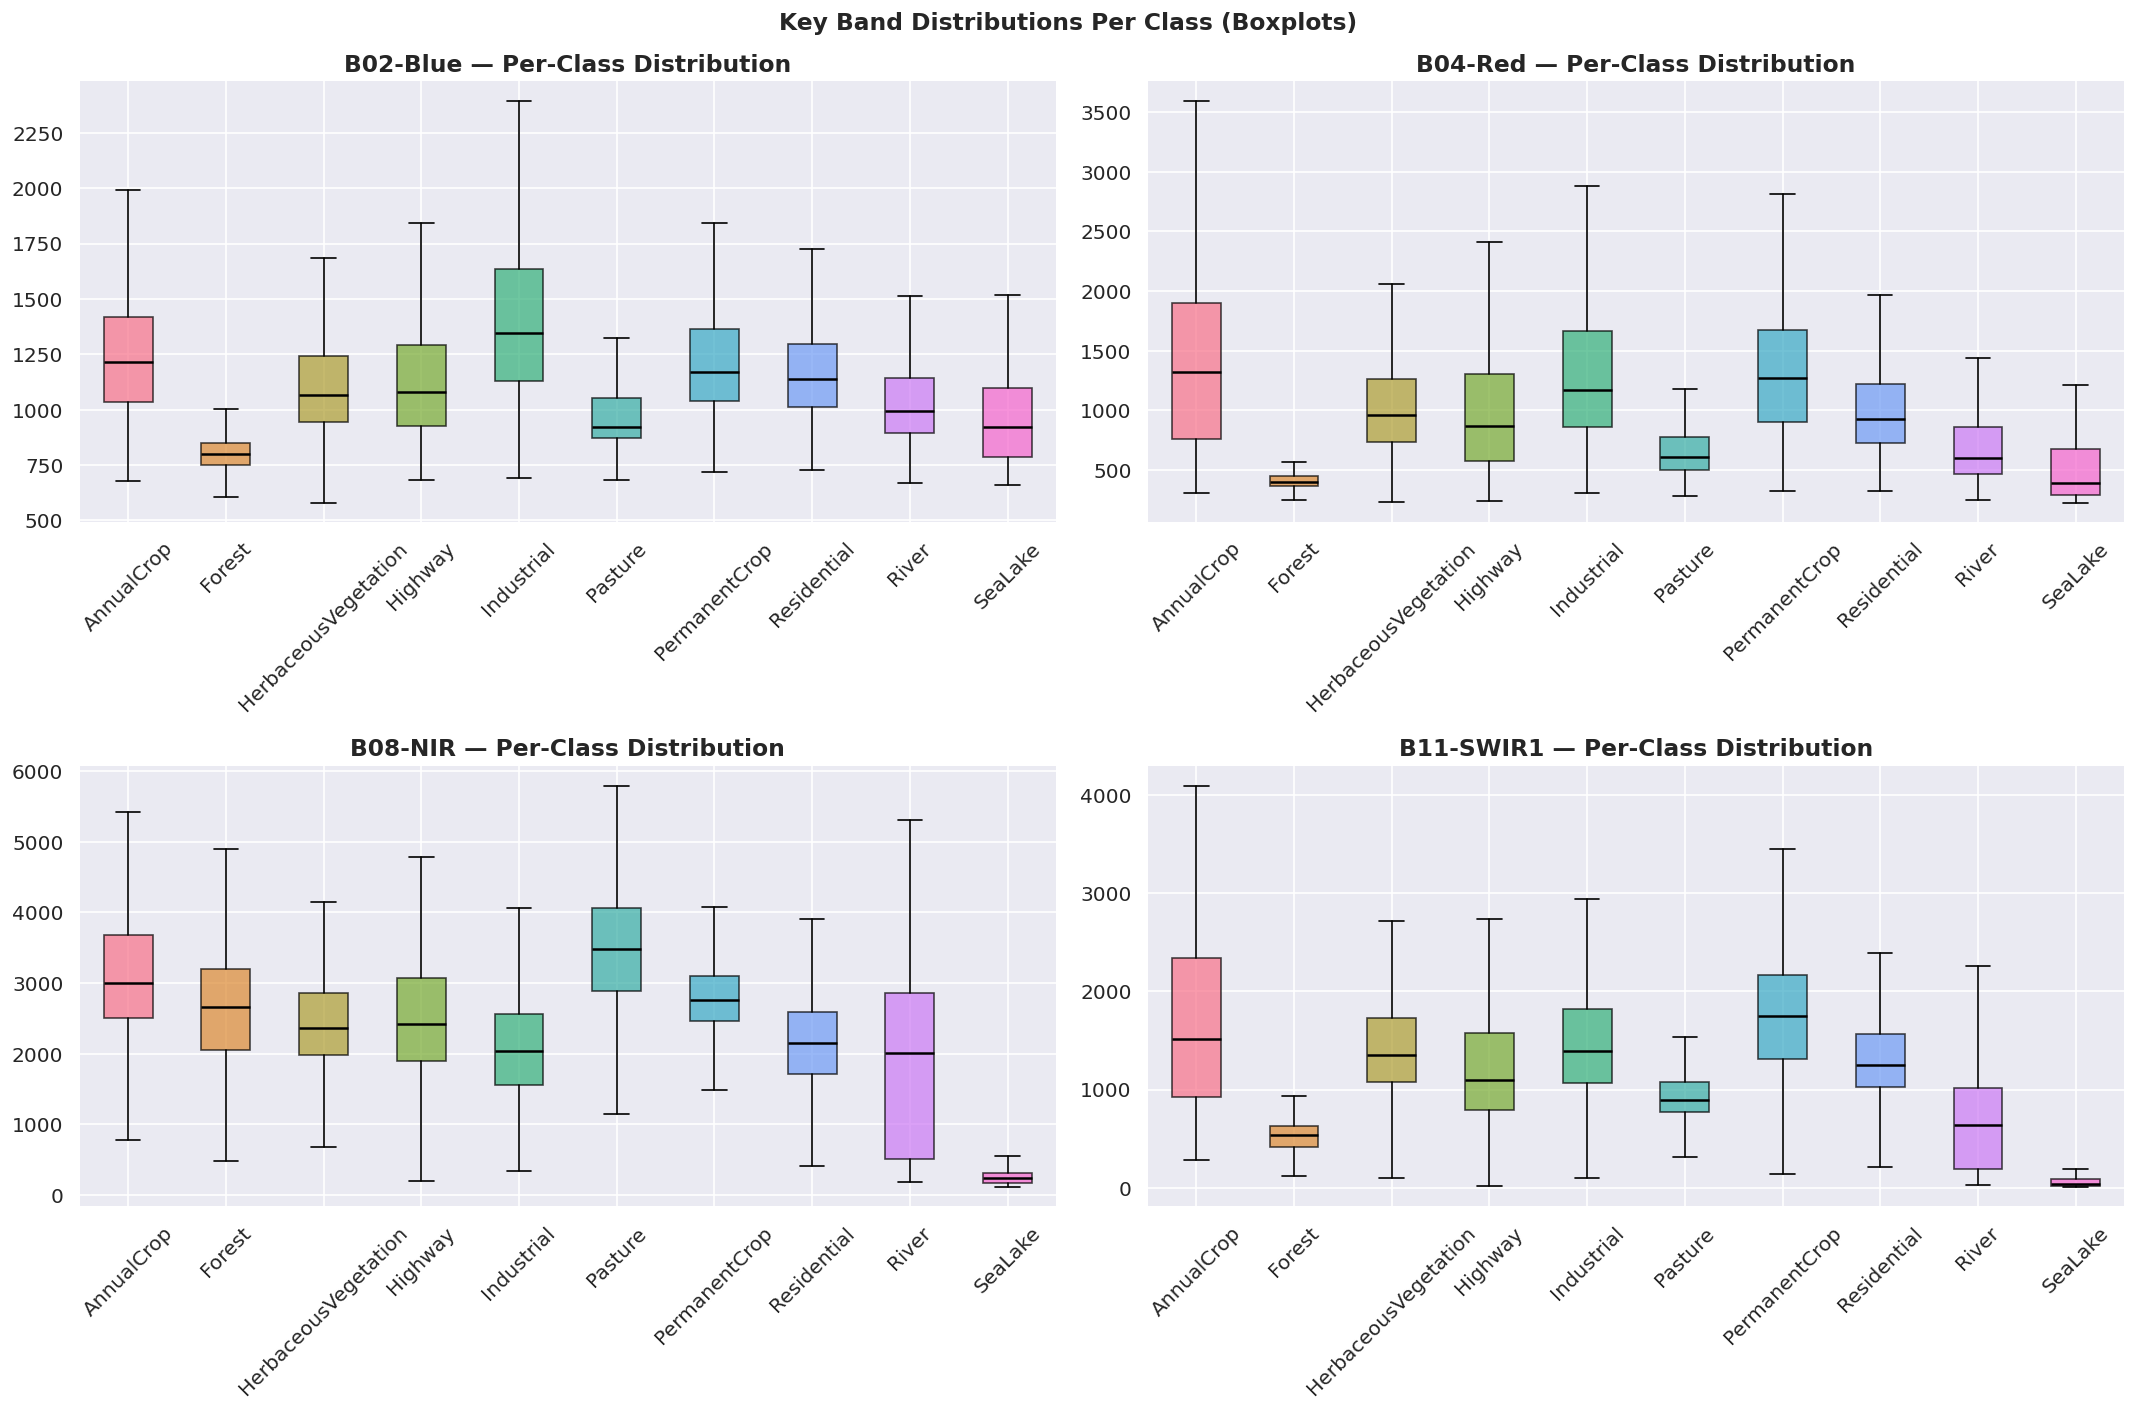

In [20]:
# Band boxplots
key_bands = [1, 3, 7, 11]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
for plot_idx, b in enumerate(key_bands):
    data_for_box = []
    for cls in CLASS_NAMES:
        vals = ms_class_data[cls][b]
        sub = np.random.choice(vals, min(5000, len(vals)), replace=False)
        data_for_box.append(sub)
    bp = axes[plot_idx].boxplot(data_for_box, labels=CLASS_NAMES, patch_artist=True,
                                 showfliers=False, medianprops={"color": "black", "linewidth": 1.5})
    for patch, color in zip(bp["boxes"], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[plot_idx].set_title(f"{BAND_NAMES[b]} — Per-Class Distribution", fontweight="bold")
    axes[plot_idx].tick_params(axis="x", rotation=45)
    axes[plot_idx].spines[["top", "right"]].set_visible(False)
plt.suptitle("Key Band Distributions Per Class (Boxplots)", fontweight="bold", fontsize=14)
plt.tight_layout()
save_fig("ms_band_boxplots.png")
plt.show()

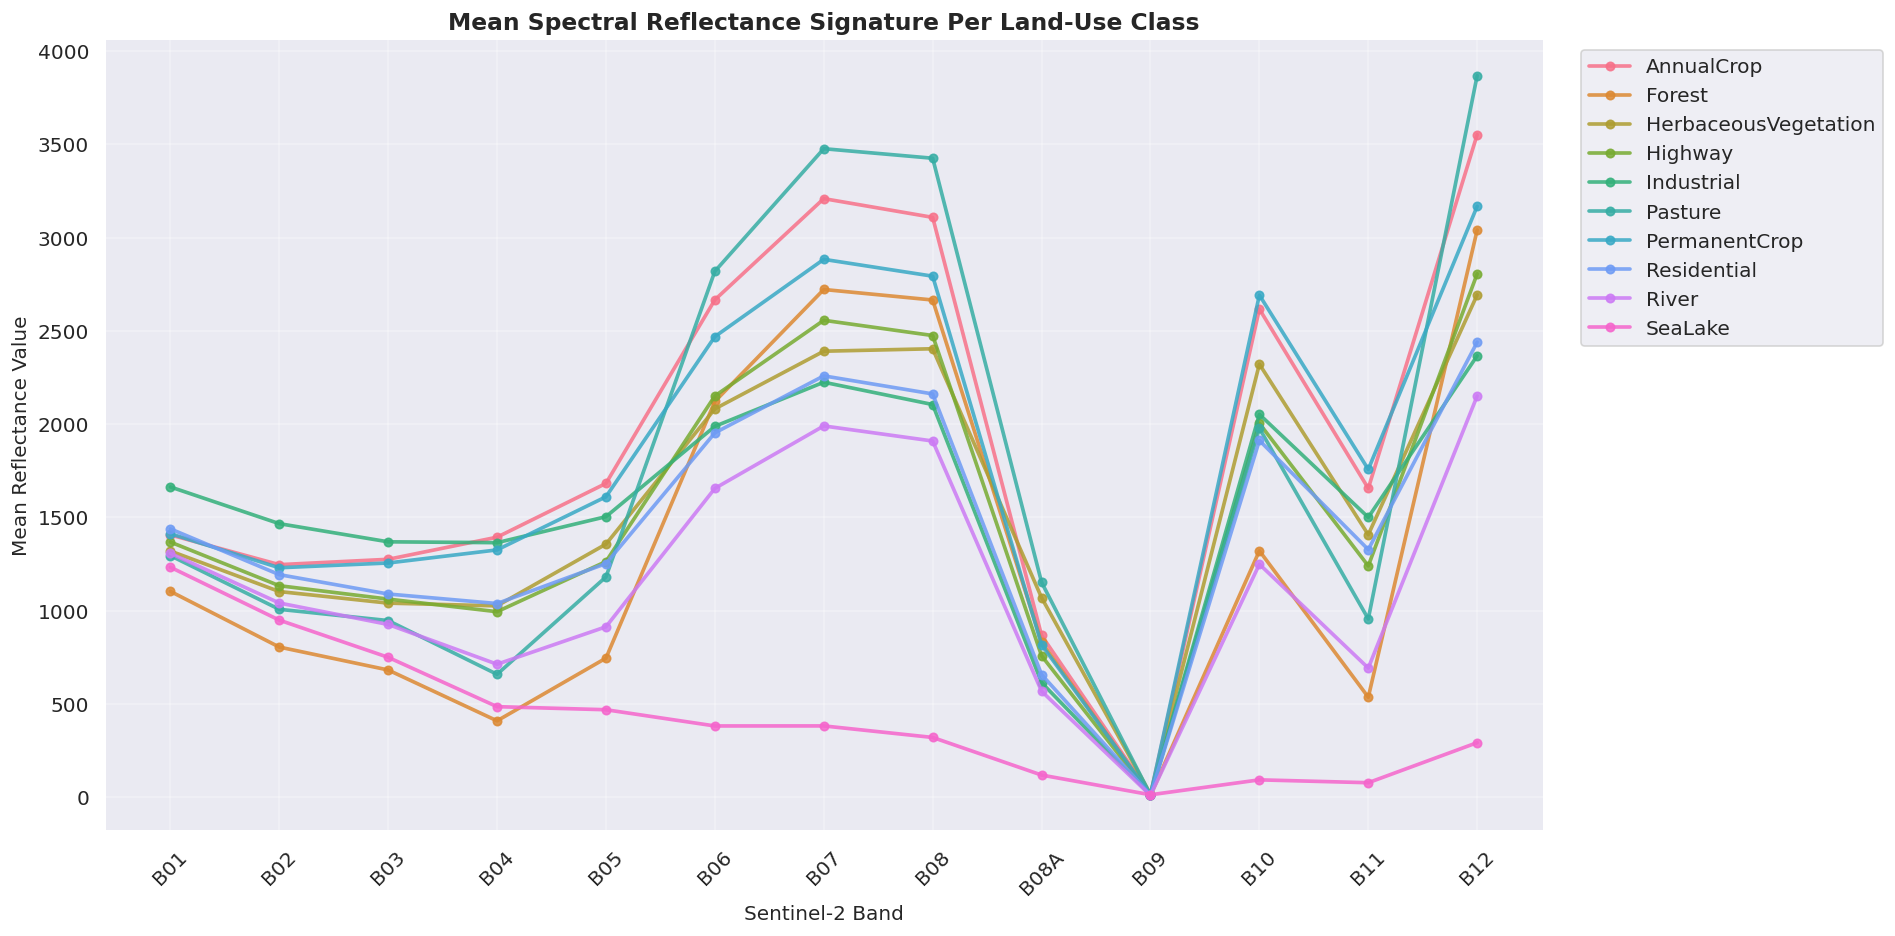

In [21]:
# Spectral signatures
fig, ax = plt.subplots(figsize=(16, 8))
spectral_signatures = {}
for cls in CLASS_NAMES:
    means = [ms_class_data[cls][b].mean() for b in range(13)]
    spectral_signatures[cls] = means
    ax.plot(range(13), means, marker="o", label=cls, linewidth=2.2, markersize=5,
            color=class_color_map[cls], alpha=0.85)
ax.set_xticks(range(13))
ax.set_xticklabels([bn.split("-")[0] for bn in BAND_NAMES], rotation=45)
ax.set_xlabel("Sentinel-2 Band")
ax.set_ylabel("Mean Reflectance Value")
ax.set_title("Mean Spectral Reflectance Signature Per Land-Use Class", fontweight="bold", fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fancybox=True)
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig("spectral_signatures.png")
plt.show()

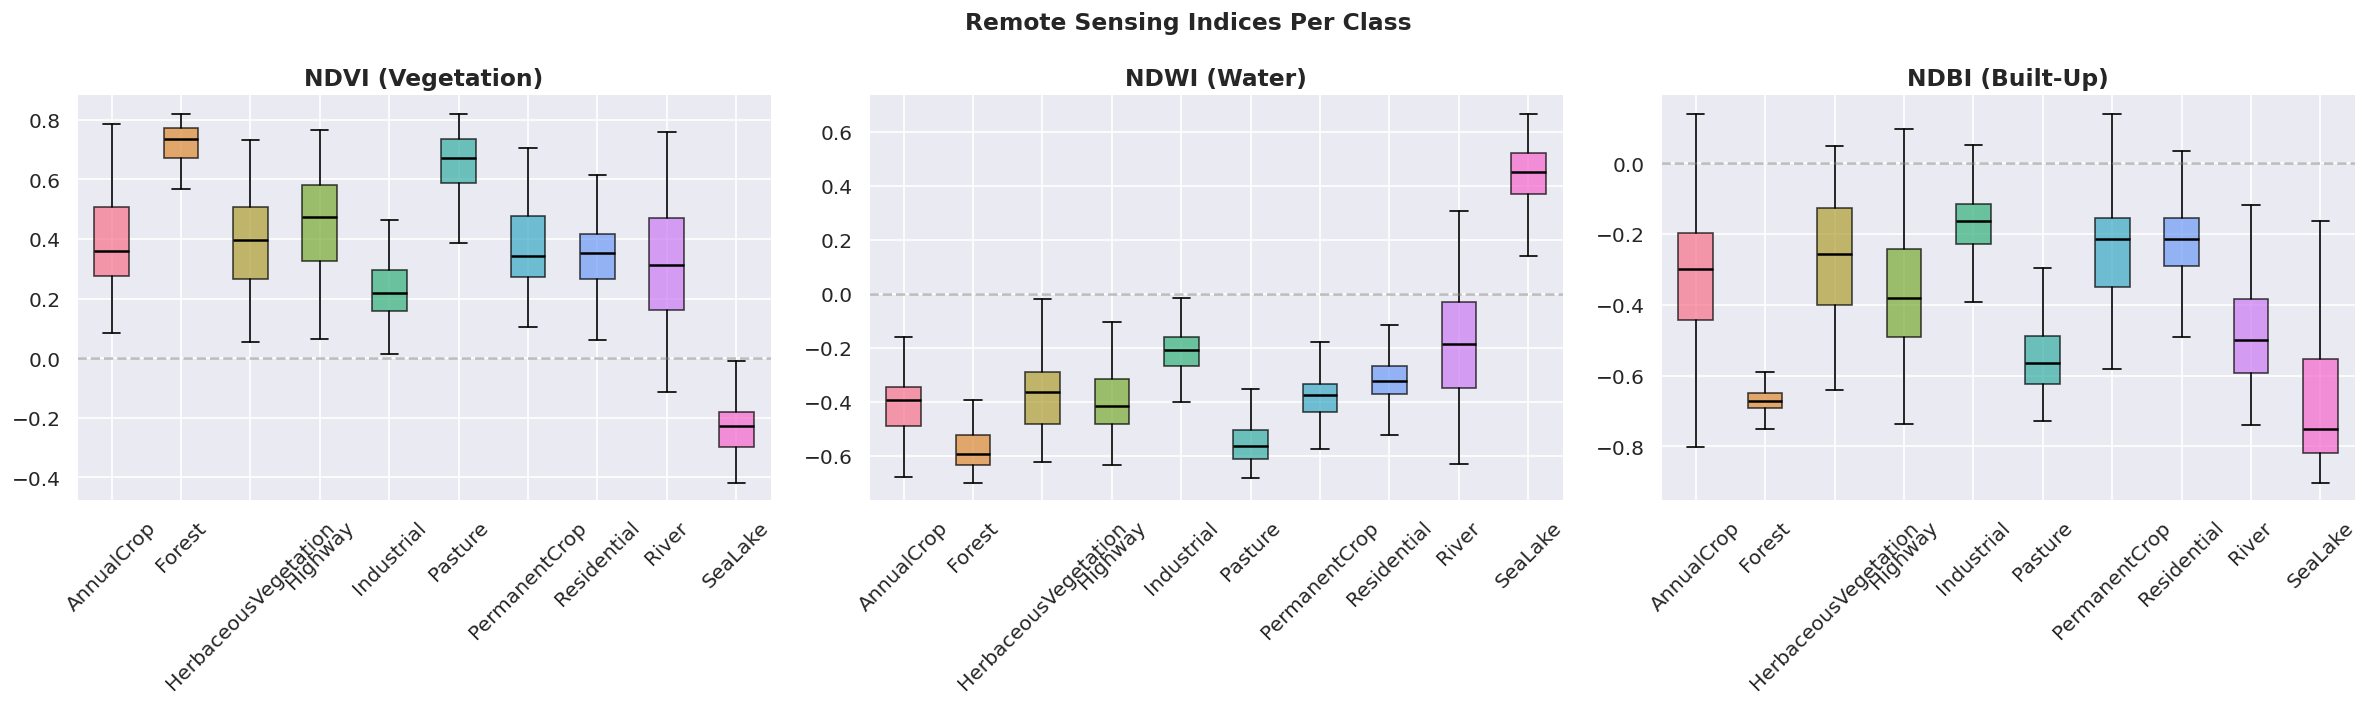

In [22]:
# Vegetation & Water Indices
def compute_index(nir, other, epsilon=1e-8):
    return (nir.astype(np.float64) - other.astype(np.float64)) / \
           (nir.astype(np.float64) + other.astype(np.float64) + epsilon)

index_data = {idx_name: {} for idx_name in ["NDVI", "NDWI", "NDBI"]}
for cls in CLASS_NAMES:
    cls_files = list((MS_DIR / cls).glob("*.tif"))
    sampled = np.random.choice(cls_files, min(200, len(cls_files)), replace=False)
    ndvi_vals, ndwi_vals, ndbi_vals = [], [], []
    for fp in sampled:
        img = load_ms_image(str(fp))
        if img is not None:
            nir  = img[:, :, B08_NIR].astype(np.float64)
            red  = img[:, :, B04_RED].astype(np.float64)
            green = img[:, :, B03_GREEN].astype(np.float64)
            swir = img[:, :, B11_SWIR1].astype(np.float64)
            ndvi_vals.append(compute_index(nir, red).mean())
            ndwi_vals.append(compute_index(green, nir).mean())
            ndbi_vals.append(compute_index(swir, nir).mean())
    index_data["NDVI"][cls] = ndvi_vals
    index_data["NDWI"][cls] = ndwi_vals
    index_data["NDBI"][cls] = ndbi_vals

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
index_titles = {"NDVI": "NDVI (Vegetation)", "NDWI": "NDWI (Water)", "NDBI": "NDBI (Built-Up)"}
for i, (idx_name, title) in enumerate(index_titles.items()):
    data_list = [index_data[idx_name][cls] for cls in CLASS_NAMES]
    bp = axes[i].boxplot(data_list, labels=CLASS_NAMES, patch_artist=True,
                          showfliers=False, medianprops={"color": "black", "linewidth": 1.5})
    for patch, color in zip(bp["boxes"], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(title, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[i].spines[["top", "right"]].set_visible(False)
plt.suptitle("Remote Sensing Indices Per Class", fontweight="bold", fontsize=14)
plt.tight_layout()
save_fig("spectral_indices.png")
plt.show()

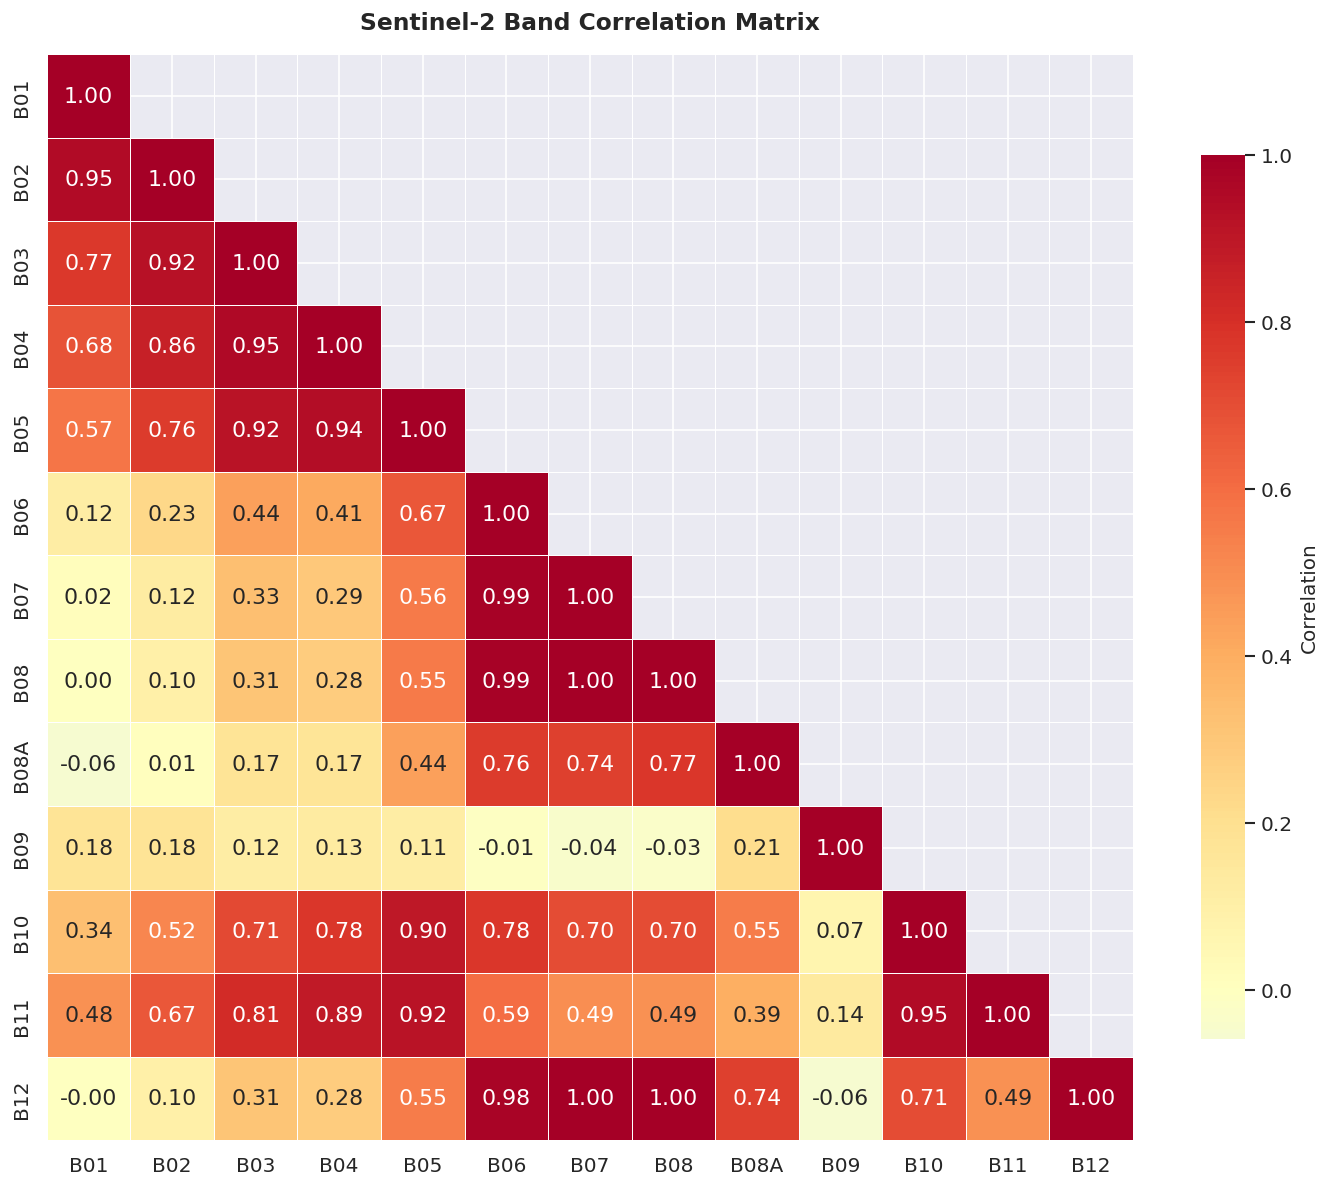

In [23]:
# Band correlation
band_matrix_rows = []
for cls in CLASS_NAMES:
    cls_files = list((MS_DIR / cls).glob("*.tif"))
    sampled = np.random.choice(cls_files, min(100, len(cls_files)), replace=False)
    for fp in sampled:
        img = load_ms_image(str(fp))
        if img is not None:
            row = [img[:, :, b].mean() for b in range(13)]
            band_matrix_rows.append(row)

band_matrix = np.array(band_matrix_rows)
corr_df = pd.DataFrame(band_matrix, columns=[bn.split("-")[0] for bn in BAND_NAMES]).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
ax.set_title("Sentinel-2 Band Correlation Matrix", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
save_fig("band_correlation.png")
plt.show()

  PART 5 — DIMENSIONALITY ANALYSIS
  Samples: 3000, Features: 13
    PC 1: 0.5682 (0.5682 cumulative)
    PC 2: 0.2713 (0.8395 cumulative)
    PC 3: 0.0811 (0.9206 cumulative)
    PC 4: 0.0413 (0.9619 cumulative)
    PC 5: 0.0227 (0.9846 cumulative)
    PC 6: 0.0110 (0.9956 cumulative)
    PC 7: 0.0020 (0.9976 cumulative)
    PC 8: 0.0011 (0.9987 cumulative)
    PC 9: 0.0009 (0.9996 cumulative)
    PC10: 0.0002 (0.9998 cumulative)
    PC11: 0.0001 (0.9999 cumulative)
    PC12: 0.0001 (1.0000 cumulative)
    PC13: 0.0000 (1.0000 cumulative)

  PCs needed for 95% variance: 4


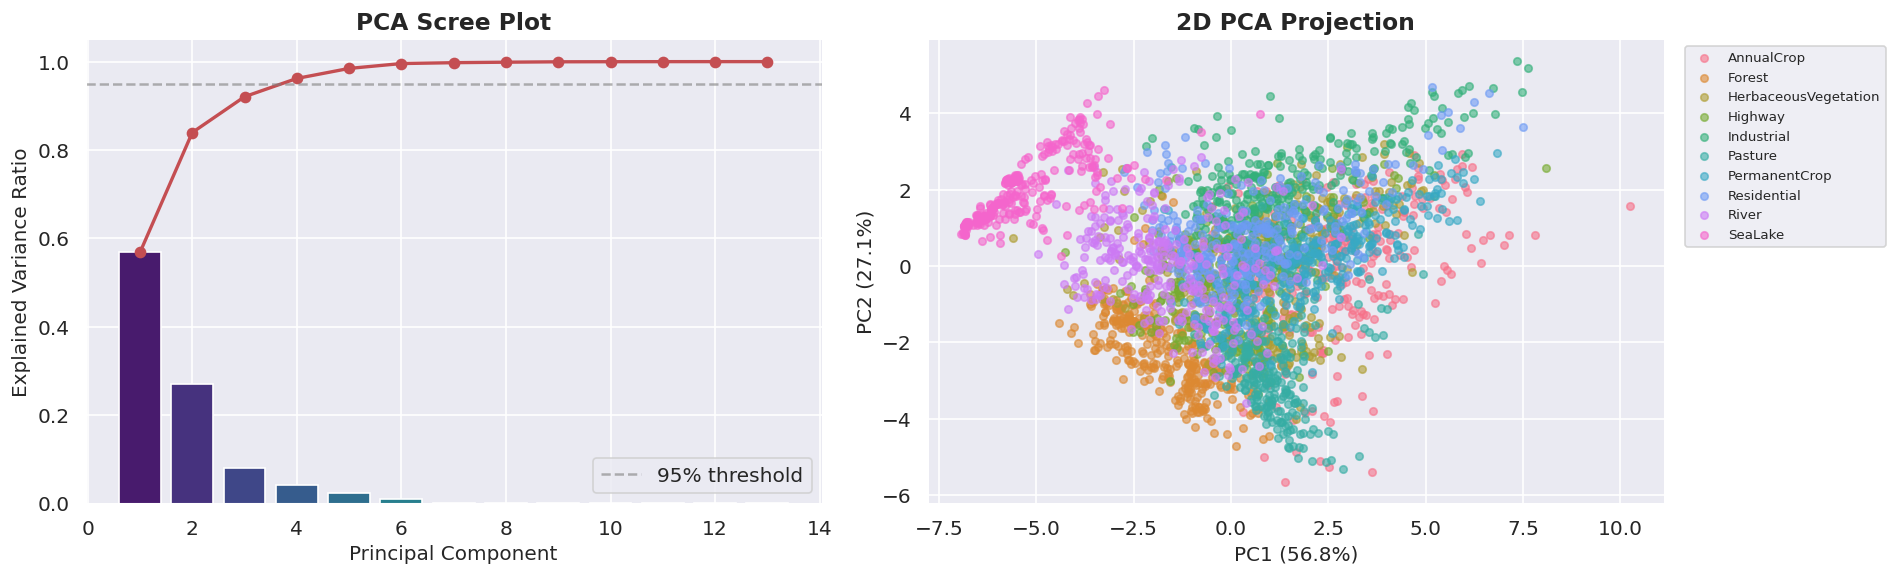

In [24]:
# ---
# ## PART 5 — DIMENSIONALITY ANALYSIS
# ---

# %%
# ============================================================
#  5.1–5.4  PCA & t-SNE
# ============================================================
print("=" * 60)
print("  PART 5 — DIMENSIONALITY ANALYSIS")
print("=" * 60)

pca_features = []
pca_labels = []
for cls in CLASS_NAMES:
    cls_files = list((MS_DIR / cls).glob("*.tif"))
    sampled = np.random.choice(cls_files, min(300, len(cls_files)), replace=False)
    for fp in sampled:
        img = load_ms_image(str(fp))
        if img is not None:
            feat = [img[:, :, b].mean() for b in range(13)]
            pca_features.append(feat)
            pca_labels.append(cls)

X = np.array(pca_features)
y = np.array(pca_labels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=13)
X_pca = pca.fit_transform(X_scaled)

print(f"  Samples: {X.shape[0]}, Features: {X.shape[1]}")
for i, evr in enumerate(pca.explained_variance_ratio_):
    cumulative = pca.explained_variance_ratio_[:i+1].sum()
    print(f"    PC{i+1:2d}: {evr:.4f} ({cumulative:.4f} cumulative)")
print(f"\n  PCs needed for 95% variance: {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(range(1, 14), pca.explained_variance_ratio_, color=sns.color_palette("viridis", 13), edgecolor="white")
axes[0].plot(range(1, 14), np.cumsum(pca.explained_variance_ratio_), "r-o", linewidth=2, markersize=6)
axes[0].axhline(y=0.95, color="gray", linestyle="--", alpha=0.6, label="95% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("PCA Scree Plot", fontweight="bold")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

for cls in CLASS_NAMES:
    m = y == cls
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], label=cls, alpha=0.6, s=20, color=class_color_map[cls])
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("2D PCA Projection", fontweight="bold")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig("pca_analysis.png")
plt.show()


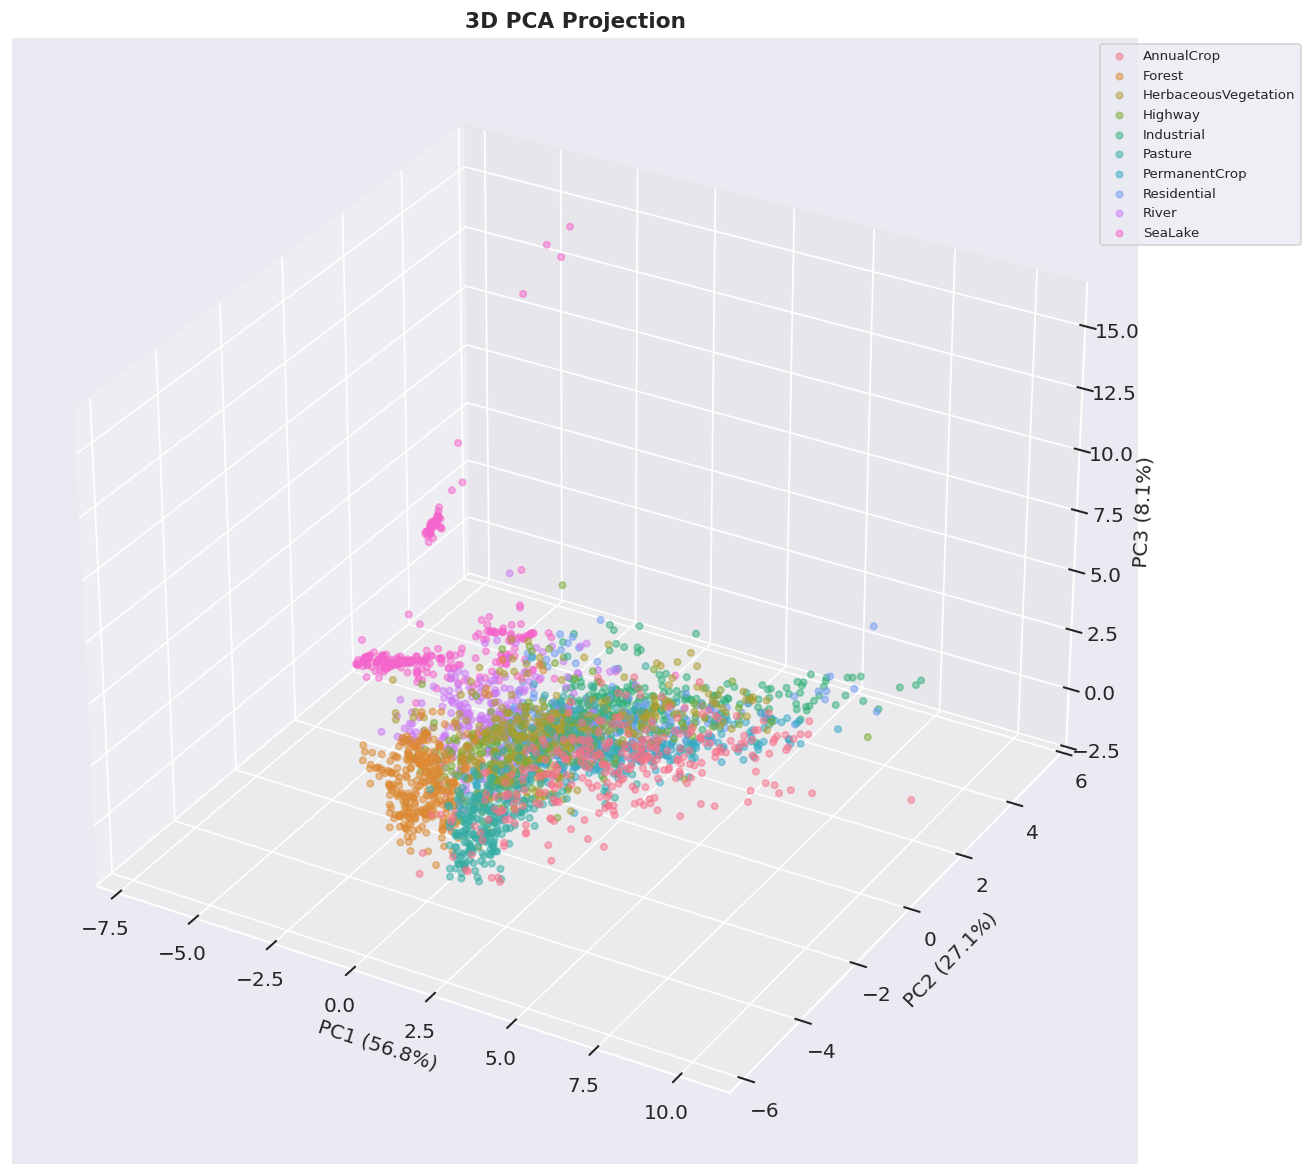

In [25]:
# 3D PCA
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
for cls in CLASS_NAMES:
    m = y == cls
    ax.scatter(X_pca[m, 0], X_pca[m, 1], X_pca[m, 2], label=cls, alpha=0.5, s=15, color=class_color_map[cls])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.set_title("3D PCA Projection", fontweight="bold", fontsize=13)
ax.legend(bbox_to_anchor=(1.15, 1), fontsize=8)
plt.tight_layout()
save_fig("pca_3d.png")
plt.show()

  Running t-SNE (this may take a minute)...


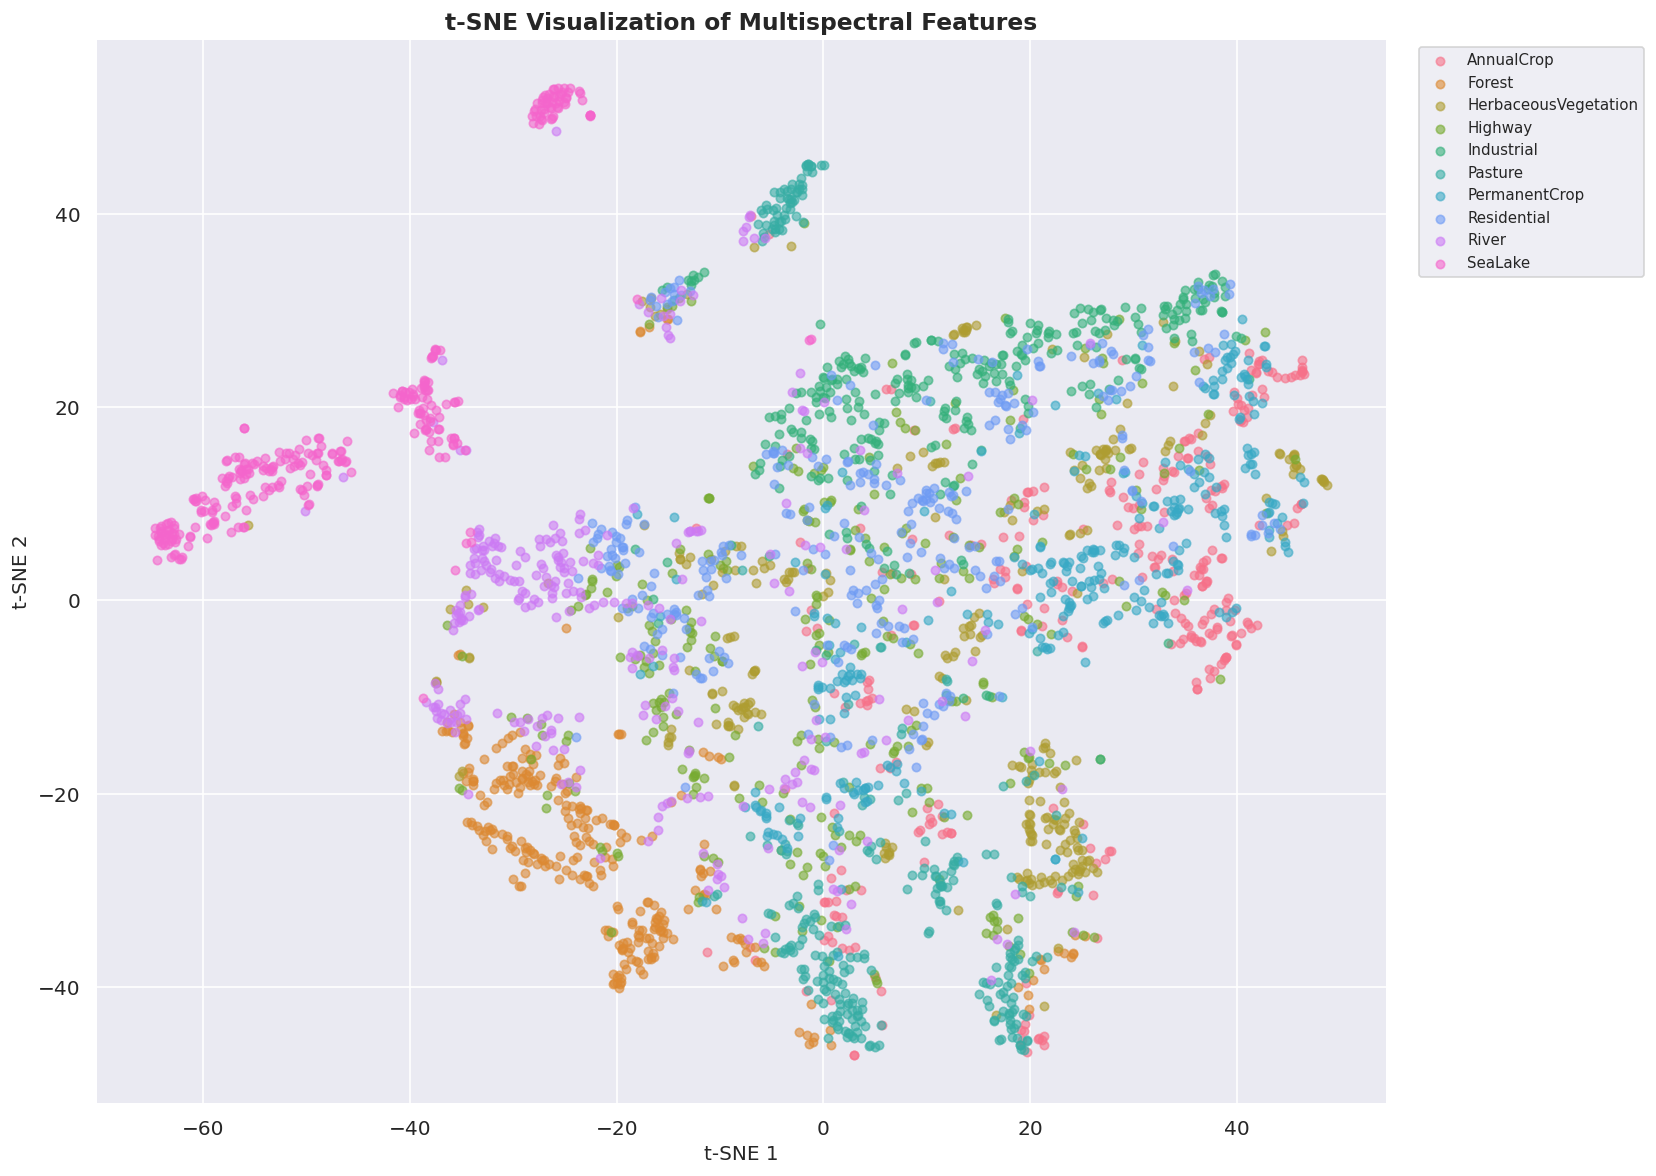

In [26]:
# t-SNE
print("  Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=40, n_iter=1000, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(14, 10))
for cls in CLASS_NAMES:
    m = y == cls
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], label=cls, alpha=0.6, s=25, color=class_color_map[cls])
ax.set_title("t-SNE Visualization of Multispectral Features", fontweight="bold", fontsize=14)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fancybox=True, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig("tsne_visualization.png")
plt.show()

In [27]:
# ---
# ## PART 6 — PREPROCESSING PIPELINE DESIGN
# ---

# %%
# ============================================================
#  6.1  RGB Preprocessing Pipeline
# ============================================================
print("=" * 60)
print("  PART 6 — PREPROCESSING PIPELINE DESIGN")
print("=" * 60)

class RGBPreprocessor:
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

    def __init__(self, target_size=(64, 64), normalize_mode="imagenet"):
        self.target_size = target_size
        self.normalize_mode = normalize_mode

    def resize(self, img):
        if img.shape[:2] != self.target_size:
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        return img

    def normalize(self, img):
        img = img.astype(np.float32) / 255.0
        if self.normalize_mode == "imagenet":
            img = (img - self.IMAGENET_MEAN) / self.IMAGENET_STD
        return img

    def augment(self, img, flip_h=True, flip_v=False, rotate=True, brightness=True):
        if flip_h and np.random.rand() > 0.5:
            img = np.fliplr(img)
        if flip_v and np.random.rand() > 0.5:
            img = np.flipud(img)
        if rotate:
            img = np.rot90(img, np.random.choice([0, 1, 2, 3]))
        if brightness:
            factor = np.random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 255).astype(np.uint8) if img.max() > 1 else np.clip(img * factor, 0, 1)
        return np.ascontiguousarray(img)

    def to_tensor(self, img):
        return np.transpose(img.astype(np.float32), (2, 0, 1))

    def __call__(self, img, augment=False):
        img = self.resize(img)
        if augment:
            img = self.augment(img)
        img = self.normalize(img)
        return self.to_tensor(img)

preproc_rgb = RGBPreprocessor(target_size=(64, 64), normalize_mode="imagenet")
demo_file = list((RGB_DIR / "Forest").glob("*.jpg"))[0]
demo_img = load_rgb_image(str(demo_file))
if demo_img is not None:
    processed = preproc_rgb(demo_img, augment=False)
    print(f"  Input shape : {demo_img.shape}, range: [{demo_img.min()}, {demo_img.max()}]")
    print(f"  Output shape: {processed.shape}, range: [{processed.min():.3f}, {processed.max():.3f}]")
    print("  ✅ RGB preprocessing pipeline working.")

  PART 6 — PREPROCESSING PIPELINE DESIGN
  Input shape : (64, 64, 3), range: [40, 90]
  Output shape: (3, 64, 64), range: [-1.433, -0.236]
  ✅ RGB preprocessing pipeline working.


In [28]:
# ============================================================
#  6.2  Multispectral Preprocessing Pipeline
# ============================================================
class MultispectralPreprocessor:
    def __init__(self, target_size=(64, 64), add_ndvi=False):
        self.target_size = target_size
        self.add_ndvi = add_ndvi

    def resize(self, img):
        if img.shape[:2] != self.target_size:
            bands = [cv2.resize(img[:, :, b], self.target_size, interpolation=cv2.INTER_LINEAR) for b in range(img.shape[2])]
            img = np.stack(bands, axis=-1)
        return img

    def normalize_per_band(self, img):
        img = img.astype(np.float32)
        for b in range(img.shape[2]):
            bmin, bmax = img[:, :, b].min(), img[:, :, b].max()
            if bmax - bmin > 0:
                img[:, :, b] = (img[:, :, b] - bmin) / (bmax - bmin)
        return img

    def add_ndvi_channel(self, img):
        nir = img[:, :, B08_NIR].astype(np.float64)
        red = img[:, :, B04_RED].astype(np.float64)
        ndvi = (nir - red) / (nir + red + 1e-8)
        return np.concatenate([img, ndvi[:, :, np.newaxis]], axis=-1)

    def __call__(self, img, normalize="per_band"):
        img = self.resize(img)
        if normalize == "per_band":
            img = self.normalize_per_band(img)
        if self.add_ndvi:
            img = self.add_ndvi_channel(img)
        return np.transpose(img.astype(np.float32), (2, 0, 1))

preproc_ms = MultispectralPreprocessor(target_size=(64, 64), add_ndvi=True)
demo_ms_file = list((MS_DIR / "Forest").glob("*.tif"))[0]
demo_ms_img = load_ms_image(str(demo_ms_file))
if demo_ms_img is not None:
    processed_ms = preproc_ms(demo_ms_img)
    print(f"  Input shape : {demo_ms_img.shape}")
    print(f"  Output shape: {processed_ms.shape} (13 bands + NDVI = 14 channels)")
    print("  ✅ Multispectral preprocessing pipeline working.")

le = LabelEncoder()
le.fit(CLASS_NAMES)
label_to_int = {name: i for i, name in enumerate(CLASS_NAMES)}
print(f"\n  Label encoding: {label_to_int}")

  Input shape : (64, 64, 13)
  Output shape: (14, 64, 64) (13 bands + NDVI = 14 channels)
  ✅ Multispectral preprocessing pipeline working.

  Label encoding: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


  PART 7 — OUTLIER & ANOMALY DETECTION
  Total images analyzed: 3000
  Brightness outliers (|z| > 3): 18


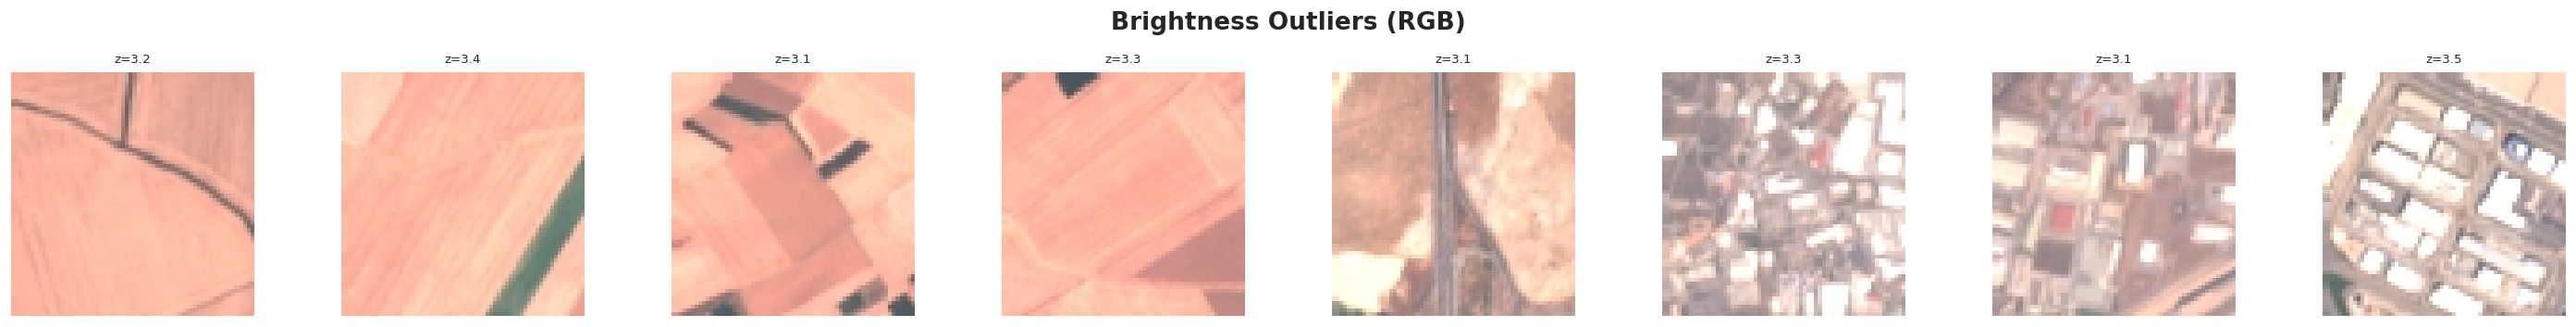

In [29]:
# ---
# ## PART 7 — OUTLIER & ANOMALY DETECTION
# ---

# %%
# ============================================================
#  7.1–7.2  Brightness & NDVI Outliers
# ============================================================
print("=" * 60)
print("  PART 7 — OUTLIER & ANOMALY DETECTION")
print("=" * 60)

brightness_per_img = []
brightness_files   = []
for cls in CLASS_NAMES:
    cls_files = list((RGB_DIR / cls).glob("*.jpg"))
    sampled = np.random.choice(cls_files, min(300, len(cls_files)), replace=False)
    for fp in sampled:
        img = load_rgb_image(str(fp))
        if img is not None:
            brightness_per_img.append(img.mean())
            brightness_files.append(str(fp))

brightness_arr = np.array(brightness_per_img)
z_scores = np.abs(stats.zscore(brightness_arr))
outlier_mask = z_scores > 3.0
print(f"  Total images analyzed: {len(brightness_arr)}")
print(f"  Brightness outliers (|z| > 3): {outlier_mask.sum()}")

if outlier_mask.sum() > 0:
    n_show = min(8, int(outlier_mask.sum()))
    outlier_indices = np.where(outlier_mask)[0]
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 3, 3))
    if n_show == 1:
        axes = [axes]
    for i, idx in enumerate(outlier_indices[:n_show]):
        img = load_rgb_image(brightness_files[idx])
        if img is not None:
            axes[i].imshow(img)
            axes[i].set_title(f"z={z_scores[idx]:.1f}", fontsize=8)
        axes[i].axis("off")
    plt.suptitle("Brightness Outliers (RGB)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  ✅ No significant brightness outliers detected.")

  NDVI outliers (|z| > 3): 13


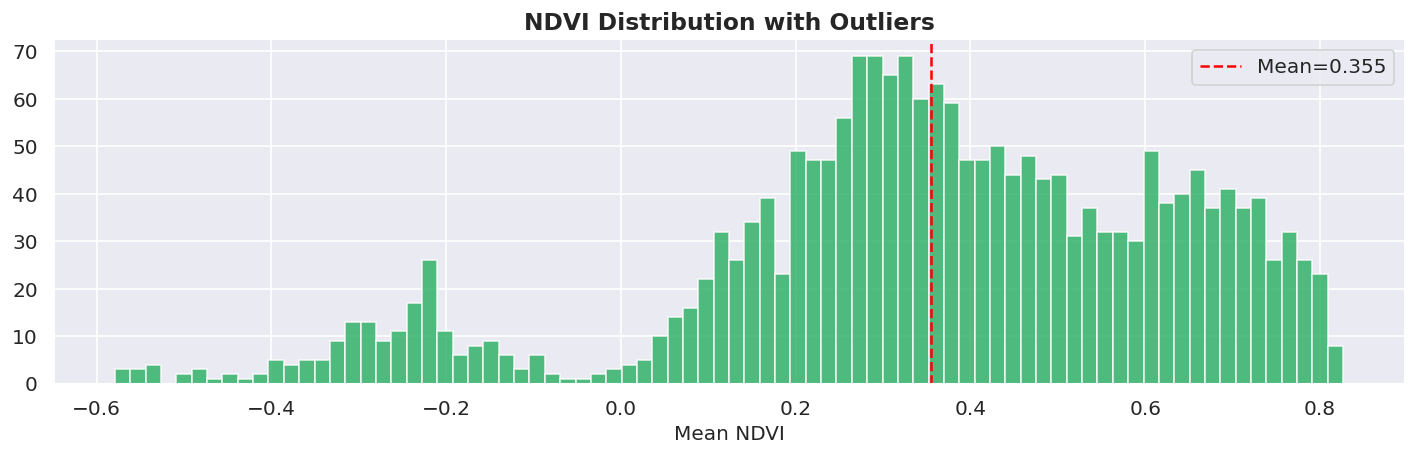

In [30]:
# NDVI outliers
all_ndvi_means = []
for cls in CLASS_NAMES:
    cls_files = list((MS_DIR / cls).glob("*.tif"))
    sampled = np.random.choice(cls_files, min(200, len(cls_files)), replace=False)
    for fp in sampled:
        img = load_ms_image(str(fp))
        if img is not None:
            nir = img[:, :, B08_NIR].astype(np.float64)
            red = img[:, :, B04_RED].astype(np.float64)
            ndvi = (nir - red) / (nir + red + 1e-8)
            all_ndvi_means.append(ndvi.mean())

ndvi_arr = np.array(all_ndvi_means)
ndvi_z = np.abs(stats.zscore(ndvi_arr))
print(f"  NDVI outliers (|z| > 3): {(ndvi_z > 3.0).sum()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(ndvi_arr, bins=80, color="#27ae60", alpha=0.8, edgecolor="white")
ax.axvline(ndvi_arr.mean(), color="red", linestyle="--", label=f"Mean={ndvi_arr.mean():.3f}")
ax.set_title("NDVI Distribution with Outliers", fontweight="bold")
ax.set_xlabel("Mean NDVI")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

  PART 8 — ADVANCED INSIGHTS & RECOMMENDATIONS

  Most similar class pairs (hardest to separate):
    HerbaceousVegetation      ↔ Highway                    dist = 538.09
    Highway                   ↔ Residential                dist = 630.81
    AnnualCrop                ↔ PermanentCrop              dist = 648.96
    Industrial                ↔ Residential                dist = 659.95
    HerbaceousVegetation      ↔ Residential                dist = 732.60


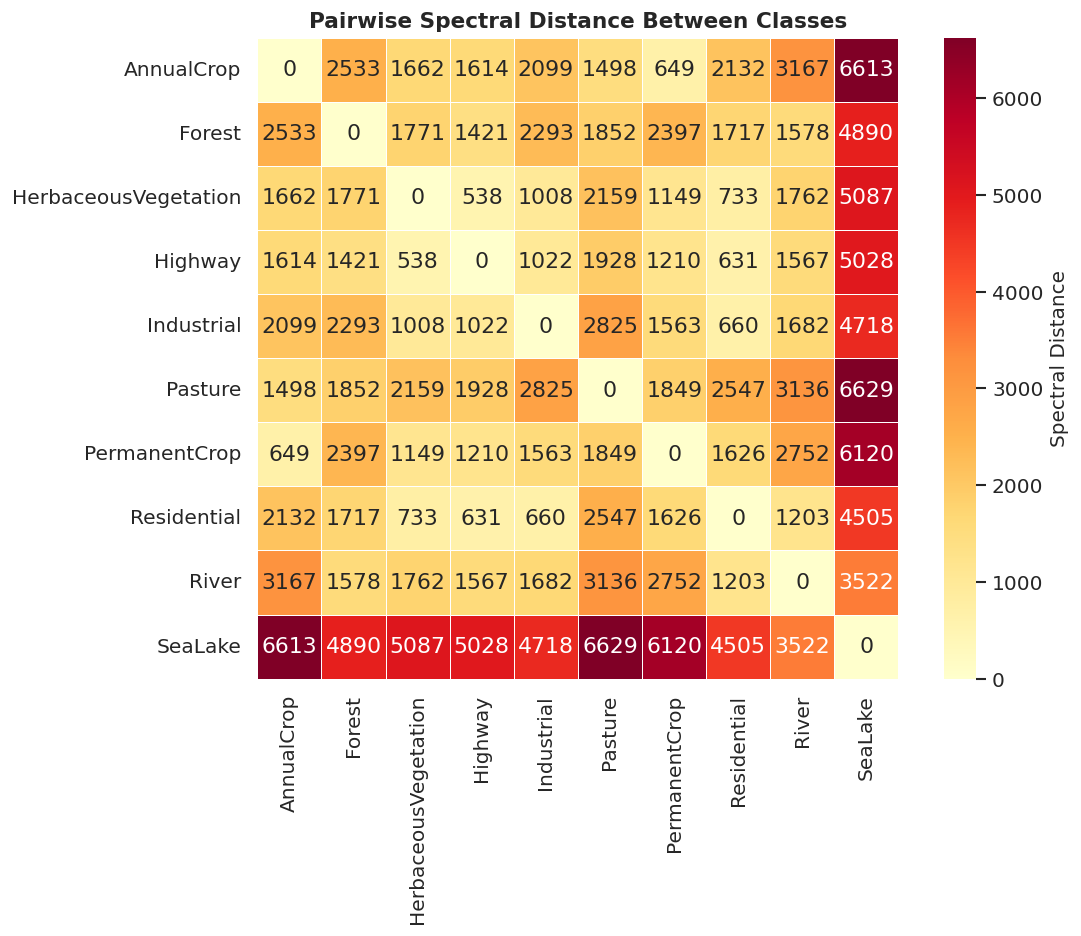

In [31]:
# ---
# ## PART 8 — ADVANCED INSIGHTS
# ---

# %%
# ============================================================
#  8.1  Advanced Insights
# ============================================================
print("=" * 70)
print("  PART 8 — ADVANCED INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

pairwise_dist = {}
for c1, c2 in combinations(CLASS_NAMES, 2):
    s1 = np.array(spectral_signatures[c1])
    s2 = np.array(spectral_signatures[c2])
    pairwise_dist[(c1, c2)] = np.linalg.norm(s1 - s2)

sorted_pairs = sorted(pairwise_dist.items(), key=lambda x: x[1])
print("\n  Most similar class pairs (hardest to separate):")
for (c1, c2), d in sorted_pairs[:5]:
    print(f"    {c1:25s} ↔ {c2:25s}  dist = {d:.2f}")

dist_matrix = pd.DataFrame(0.0, index=CLASS_NAMES, columns=CLASS_NAMES)
for (c1, c2), d in pairwise_dist.items():
    dist_matrix.loc[c1, c2] = d
    dist_matrix.loc[c2, c1] = d
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dist_matrix.astype(float), annot=True, fmt=".0f", cmap="YlOrRd",
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Spectral Distance"})
ax.set_title("Pairwise Spectral Distance Between Classes", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("pairwise_spectral_distance.png")
plt.show()

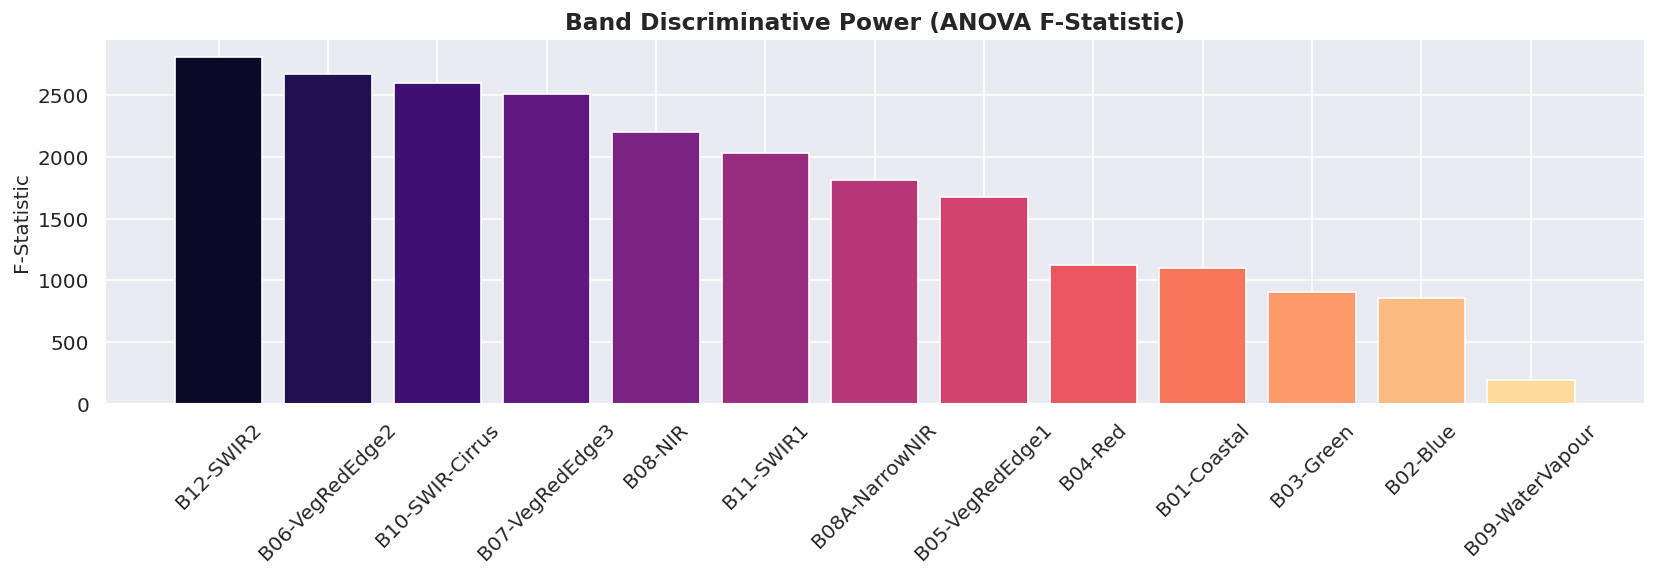


✅ EDA COMPLETE. Moving to model development.


In [32]:
# Discriminative power
from scipy.stats import f_oneway
f_scores = {}
for b in range(13):
    groups = [ms_class_data[cls][b] for cls in CLASS_NAMES]
    groups_sub = [np.random.choice(g, min(2000, len(g)), replace=False) for g in groups]
    f_stat, p_val = f_oneway(*groups_sub)
    f_scores[BAND_NAMES[b]] = {"F-statistic": f_stat, "p-value": p_val}

f_df = pd.DataFrame(f_scores).T.sort_values("F-statistic", ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(f_df.index, f_df["F-statistic"], color=sns.color_palette("magma", 13), edgecolor="white")
ax.set_title("Band Discriminative Power (ANOVA F-Statistic)", fontweight="bold")
ax.set_ylabel("F-Statistic")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig("band_discriminative_power.png")
plt.show()

print("\n✅ EDA COMPLETE. Moving to model development.")
print("=" * 70)

In [33]:
# ============================================================
#  CHUNK 9 — DATA GENERATORS (RGB & TIF) — MEMORY EFFICIENT
# ============================================================
# CSV splits are already loaded in Part 1. We reference them directly.

train_rgb_df = train_rgb
val_rgb_df   = val_rgb
test_rgb_df  = test_rgb
train_ms_df  = train_ms
val_ms_df    = val_ms
test_ms_df   = test_ms

print(f"📄 RGB  — Train: {len(train_rgb_df)} | Val: {len(val_rgb_df)} | Test: {len(test_rgb_df)}")
print(f"📄 TIF  — Train: {len(train_ms_df)}  | Val: {len(val_ms_df)}  | Test: {len(test_ms_df)}")

# ── Preprocessing functions ──

def load_and_preprocess_rgb_model(filepath, augment=False):
    """Load RGB image, resize to 224×224, normalize with ImageNet stats."""
    img = Image.open(filepath).convert("RGB")
    img = img.resize(RGB_IMG_SIZE, Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    if augment:
        if np.random.rand() > 0.5:
            img = np.fliplr(img)
        if np.random.rand() > 0.5:
            img = np.flipud(img)
        k = np.random.choice([0, 1, 2, 3])
        img = np.rot90(img, k)
        factor = np.random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return np.ascontiguousarray(img, dtype=np.float32)

def load_and_preprocess_tif_model(filepath):
    """Load a multispectral .tif image and normalize per-band to [0, 1]."""
    with rasterio.open(filepath) as src:
        data = src.read()
    img = np.transpose(data, (1, 2, 0)).astype(np.float32)
    for b in range(img.shape[2]):
        bmin, bmax = img[:, :, b].min(), img[:, :, b].max()
        if bmax - bmin > 0:
            img[:, :, b] = (img[:, :, b] - bmin) / (bmax - bmin)
        else:
            img[:, :, b] = 0.0
    return img

# ── Lazy dataset builders (train & val — never load all into RAM) ──

def build_rgb_dataset_lazy(df, base_dir, augment=False, shuffle=True):
    """Build a tf.data.Dataset that loads RGB images lazily (one at a time)."""
    filepaths = [str(base_dir / row["Filename"]) for _, row in df.iterrows()]
    int_labels = [label_to_int[c] for c in df["ClassName"]]
    n_samples = len(filepaths)

    def generator():
        indices = list(range(n_samples))
        if shuffle:
            np.random.shuffle(indices)
        for idx in indices:
            try:
                img = load_and_preprocess_rgb_model(filepaths[idx], augment=augment)
                lbl = to_categorical(int_labels[idx], NUM_CLASSES).astype(np.float32)
                yield img, lbl
            except Exception:
                continue

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(*RGB_IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
        )
    )
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds, n_samples

def build_tif_dataset_lazy(df, base_dir, shuffle=True):
    """Build a tf.data.Dataset that loads TIF images lazily (one at a time)."""
    filepaths = [str(base_dir / row["Filename"]) for _, row in df.iterrows()]
    int_labels = [label_to_int[c] for c in df["ClassName"]]
    n_samples = len(filepaths)

    def generator():
        indices = list(range(n_samples))
        if shuffle:
            np.random.shuffle(indices)
        for idx in indices:
            try:
                img = load_and_preprocess_tif_model(filepaths[idx])
                lbl = to_categorical(int_labels[idx], NUM_CLASSES).astype(np.float32)
                yield img, lbl
            except Exception:
                continue

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(*TIF_IMG_SIZE, 13), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
        )
    )
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds, n_samples

# ── Test data loaders (ONLY test sets go into memory — small enough) ──

def load_test_rgb(df, base_dir):
    """Load test RGB images into memory for evaluation."""
    filepaths = [str(base_dir / row["Filename"]) for _, row in df.iterrows()]
    int_labels = [label_to_int[c] for c in df["ClassName"]]
    images, labels = [], []
    for fp, lbl_int in zip(filepaths, int_labels):
        try:
            img = load_and_preprocess_rgb_model(fp, augment=False)
            images.append(img)
            labels.append(lbl_int)
        except Exception:
            continue
    X = np.array(images, dtype=np.float32)
    Y = to_categorical(labels, NUM_CLASSES).astype(np.float32)
    return X, Y

def load_test_tif(df, base_dir):
    """Load test TIF images into memory for evaluation."""
    filepaths = [str(base_dir / row["Filename"]) for _, row in df.iterrows()]
    int_labels = [label_to_int[c] for c in df["ClassName"]]
    images, labels = [], []
    for fp, lbl_int in zip(filepaths, int_labels):
        try:
            img = load_and_preprocess_tif_model(fp)
            images.append(img)
            labels.append(lbl_int)
        except Exception:
            continue
    X = np.array(images, dtype=np.float32)
    Y = to_categorical(labels, NUM_CLASSES).astype(np.float32)
    return X, Y

# ── Build all datasets ──

print("🔄 Building RGB datasets (lazy generators — no RAM spike)...")
train_rgb_ds, n_train_rgb = build_rgb_dataset_lazy(train_rgb_df, RGB_DIR, augment=True, shuffle=True)
val_rgb_ds,   n_val_rgb   = build_rgb_dataset_lazy(val_rgb_df,   RGB_DIR, augment=False, shuffle=False)
print(f"   Train: {n_train_rgb} samples | Val: {n_val_rgb} samples")

print("🔄 Loading RGB test set into memory...")
X_test_rgb, Y_test_rgb = load_test_rgb(test_rgb_df, RGB_DIR)
print(f"✅ RGB ready — Test: {X_test_rgb.shape}")

gc.collect()

print("🔄 Building TIF datasets (lazy generators — no RAM spike)...")
train_tif_ds, n_train_tif = build_tif_dataset_lazy(train_ms_df, MS_DIR, shuffle=True)
val_tif_ds,   n_val_tif   = build_tif_dataset_lazy(val_ms_df,   MS_DIR, shuffle=False)
print(f"   Train: {n_train_tif} samples | Val: {n_val_tif} samples")

print("🔄 Loading TIF test set into memory...")
X_test_tif, Y_test_tif = load_test_tif(test_ms_df, MS_DIR)
print(f"✅ TIF ready — Test: {X_test_tif.shape}")

gc.collect()
print("✅ All datasets ready (memory-efficient mode).")

📄 RGB  — Train: 18900 | Val: 5400 | Test: 2700
📄 TIF  — Train: 19317  | Val: 5519  | Test: 2759
🔄 Building RGB datasets (lazy generators — no RAM spike)...


I0000 00:00:1773864155.680689      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773864155.686673      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


   Train: 18900 samples | Val: 5400 samples
🔄 Loading RGB test set into memory...
✅ RGB ready — Test: (2700, 224, 224, 3)
🔄 Building TIF datasets (lazy generators — no RAM spike)...
   Train: 19317 samples | Val: 5519 samples
🔄 Loading TIF test set into memory...
✅ TIF ready — Test: (2759, 64, 64, 13)
✅ All datasets ready (memory-efficient mode).


In [34]:
# ============================================================
#  CHUNK 10 — TIF MODEL ARCHITECTURE
# ============================================================

def _identity_block(x, filters):
    """Identity residual block — dimensions stay the same."""
    f1, f2, f3 = filters
    shortcut = x
    x = layers.Conv2D(f1, (1, 1), padding="valid")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(f2, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(f3, (1, 1), padding="valid")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def _convolutional_block(x, filters, strides=(2, 2)):
    """Convolutional residual block — dimensions change via stride."""
    f1, f2, f3 = filters
    shortcut = layers.Conv2D(f3, (1, 1), strides=strides, padding="valid")(x)
    shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Conv2D(f1, (1, 1), strides=strides, padding="valid")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(f2, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(f3, (1, 1), padding="valid")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_tif_resnet50(input_shape=(64, 64, 13), num_classes=10):
    """Custom ResNet-50 inspired model for 13-band multispectral input."""
    inputs = layers.Input(shape=input_shape, name="tif_input")
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding="same", name="initial_conv")(inputs)
    x = layers.BatchNormalization(name="initial_bn")(x)
    x = layers.Activation("relu", name="initial_relu")(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding="same", name="initial_pool")(x)
    # Stage 1
    x = _convolutional_block(x, filters=(64, 64, 256), strides=(1, 1))
    x = _identity_block(x, filters=(64, 64, 256))
    x = _identity_block(x, filters=(64, 64, 256))
    # Stage 2
    x = _convolutional_block(x, filters=(128, 128, 512), strides=(2, 2))
    x = _identity_block(x, filters=(128, 128, 512))
    x = _identity_block(x, filters=(128, 128, 512))
    x = _identity_block(x, filters=(128, 128, 512))
    # Stage 3
    x = _convolutional_block(x, filters=(256, 256, 1024), strides=(2, 2))
    x = _identity_block(x, filters=(256, 256, 1024))
    x = _identity_block(x, filters=(256, 256, 1024))
    # Head
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(512, activation="relu", name="fc_512")(x)
    x = layers.Dropout(0.5, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    return models.Model(inputs=inputs, outputs=outputs, name="TIF_CustomResNet50")

tif_model = build_tif_resnet50(input_shape=(64, 64, 13), num_classes=NUM_CLASSES)
tif_model.summary()
print(f"\n🏗️ TIF Model built — Total parameters: {tif_model.count_params():,}")

Model: "TIF_CustomResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tif_input           │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 13)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 32, 32,    │     40,832 │ tif_input[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 32, 32,    │        256 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_relu        │ (None, 32, 32,    │          0 │ initial_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_pool        │ (None, 16, 16,    │          0 │ initial_relu[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │      4,160 │ initial_pool[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     16,640 │ activation_1[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │     16,640 │ initial_pool[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │      1,024 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ add[0][0]       

 Total params: 5,785,098 (22.07 MB)

 Trainable params: 5,763,722 (21.99 MB)

 Non-trainable params: 21,376 (83.50 KB)


🏗️ TIF Model built — Total parameters: 5,785,098


In [35]:
# ---
# ## CHUNK 11 — RGB MODEL (Transfer Learning ResNet-50)
# ---

# %%
# ============================================================
#  CHUNK 11 — RGB MODEL ARCHITECTURE
# ============================================================

def build_rgb_resnet50(input_shape=(224, 224, 3), num_classes=10):
    """Transfer learning model using pretrained ResNet-50 (ImageNet)."""
    base_model = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False
    inputs = layers.Input(shape=input_shape, name="rgb_input")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(512, activation="relu", name="fc_512")(x)
    x = layers.Dropout(0.5, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    return models.Model(inputs=inputs, outputs=outputs, name="RGB_TransferResNet50")

rgb_model = build_rgb_resnet50(input_shape=(*RGB_IMG_SIZE, 3), num_classes=NUM_CLASSES)
rgb_model.summary()

total_params = rgb_model.count_params()
trainable_params = int(np.sum([np.prod(w.shape) for w in rgb_model.trainable_weights]))
frozen_params = total_params - trainable_params
print(f"\n🔄 RGB Model built — Total: {total_params:,} | Trainable: {trainable_params:,} | Frozen: {frozen_params:,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "RGB_TransferResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_512 (Dense)                  │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 1,054,218 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


🔄 RGB Model built — Total: 24,641,930 | Trainable: 1,054,218 | Frozen: 23,587,712


In [36]:
# ============================================================
#  CHUNK 12 — COMPILE & TRAIN BOTH MODELS
# ============================================================
import time

tif_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
rgb_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

def get_callbacks(model_name):
    """Create training callbacks — saves checkpoints to OUTPUT_DIR."""
    return [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=8,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=4, min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=str(OUTPUT_DIR / f"best_{model_name}.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=1
        )
    ]

print("=" * 70)
print("  TRAINING TIF MODEL (Custom ResNet-50)")
print("=" * 70)
tif_start = time.time()
tif_history = tif_model.fit(
    train_tif_ds, validation_data=val_tif_ds,
    epochs=EPOCHS, callbacks=get_callbacks("tif_model"), verbose=1
)
tif_train_time = time.time() - tif_start
print(f"\n⏱️ TIF training time: {tif_train_time:.1f}s ({tif_train_time/60:.1f} min)")

print("\n" + "=" * 70)
print("  TRAINING RGB MODEL (Transfer Learning ResNet-50)")
print("=" * 70)
rgb_start = time.time()
rgb_history = rgb_model.fit(
    train_rgb_ds, validation_data=val_rgb_ds,
    epochs=EPOCHS, callbacks=get_callbacks("rgb_model"), verbose=1
)
rgb_train_time = time.time() - rgb_start
print(f"\n⏱️ RGB training time: {rgb_train_time:.1f}s ({rgb_train_time/60:.1f} min)")
print("\n✅ Both models trained successfully!")


  TRAINING TIF MODEL (Custom ResNet-50)
Epoch 1/50


I0000 00:00:1773864222.740118      70 service.cc:152] XLA service 0x7e0950058ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773864222.740155      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773864222.740159      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773864226.269714      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


      2/Unknown 33s 54ms/step - accuracy: 0.1250 - loss: 4.1772

I0000 00:00:1773864237.600949      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    604/Unknown 284s 416ms/step - accuracy: 0.4640 - loss: 1.7568
Epoch 1: val_accuracy improved from -inf to 0.24697, saving model to /kaggle/working/best_tif_model.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 358s 538ms/step - accuracy: 0.4642 - loss: 1.7561 - val_accuracy: 0.2470 - val_loss: 6.9764 - learning_rate: 0.0010
Epoch 2/50
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6925 - loss: 0.9251
Epoch 2: val_accuracy improved from 0.24697 to 0.58090, saving model to /kaggle/working/best_tif_model.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 105s 174ms/step - accuracy: 0.6925 - loss: 0.9250 - val_accuracy: 0.5809 - val_loss: 1.5383 - learning_rate: 0.0010
Epoch 3/50
604/604 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7720 - loss: 0.6833
Epoch 3: val_accuracy improved from 0.58090 to 0.64976, saving model to /kaggle/working/best_tif_model.keras
604/604 ━━━━━━━━━━━━━━━━━━━━ 107s 176ms/step - accuracy: 0.7720 - loss: 0.6833 - val_accuracy: 0.6498 - val_loss: 1.1839 - learning_rate: 0.0010

In [37]:
# ============================================================
#  CHUNK 13 — LEARNING CURVES (shared function)
# ============================================================

def plot_learning_curves(history, model_name, save_prefix):
    """Plot training/validation accuracy & loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    epochs_range = range(1, len(history.history["accuracy"]) + 1)

    # Accuracy
    axes[0].plot(epochs_range, history.history["accuracy"],
                 "b-o", label="Training Accuracy", linewidth=2, markersize=4)
    axes[0].plot(epochs_range, history.history["val_accuracy"],
                 "r-s", label="Validation Accuracy", linewidth=2, markersize=4)
    best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
    best_val_acc = max(history.history["val_accuracy"])
    axes[0].axvline(x=best_epoch, color="green", linestyle="--",
                    alpha=0.6, label=f"Best Epoch: {best_epoch}")
    axes[0].set_title(f"{model_name} — Accuracy", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(frameon=True, fancybox=True, shadow=True)
    axes[0].grid(True, alpha=0.3)
    axes[0].spines[["top", "right"]].set_visible(False)

    # Loss
    axes[1].plot(epochs_range, history.history["loss"],
                 "b-o", label="Training Loss", linewidth=2, markersize=4)
    axes[1].plot(epochs_range, history.history["val_loss"],
                 "r-s", label="Validation Loss", linewidth=2, markersize=4)
    axes[1].axvline(x=best_epoch, color="green", linestyle="--",
                    alpha=0.6, label=f"Best Epoch: {best_epoch}")
    axes[1].set_title(f"{model_name} — Loss", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(frameon=True, fancybox=True, shadow=True)
    axes[1].grid(True, alpha=0.3)
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"{model_name} — Learning Curves",
                 fontweight="bold", fontsize=15, y=1.02)
    plt.tight_layout()
    save_fig(f"{save_prefix}_learning_curves.png")
    plt.show()

    print(f"\n📊 {model_name} Training Summary:")
    print(f"   Total epochs trained: {len(history.history['accuracy'])}")
    print(f"   Best epoch:           {best_epoch}")
    print(f"   Best val accuracy:    {best_val_acc:.4f}")
    print(f"   Final train accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"   Final val accuracy:   {history.history['val_accuracy'][-1]:.4f}")